In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.spatial.distance import cdist
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import gseapy as gp
from gseapy.parser import download_library
from gseapy import barplot, dotplot
from matplotlib_venn import venn2, venn3
import textwrap
from collections import Counter
from collections import defaultdict

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load in processed AnnData

In [2]:
%%time

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 

adata

Memory usage: current 2.57 GB, difference +2.57 GB
CPU times: user 592 ms, sys: 1.58 s, total: 2.17 s
Wall time: 7.13 s


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [3]:
# Ensure working with raw counts
adata.X = adata.layers['raw_counts']

# Extract MYOD1 expression as a dense 1D array
myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# Initial number of cells
init_cells = adata.n_obs

# Create exclusion masks
remove_siPRRX1 = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)
remove_mmMYOD1  = (adata.obs['pooled_condition'] == 'mmMYOD1') & (myod1_expr == 0)

# Combine both masks
mask_remove = remove_siPRRX1 | remove_mmMYOD1

# Keep only cells not in the mask
adata = adata[~mask_remove].copy()

# Final cell count
final_cells = adata.n_obs
print(f"Removed {init_cells - final_cells} cells total:")
print(f"  - {remove_siPRRX1.sum()} siPRRX1 cells with non-zero MYOD1 expression")
print(f"  - {remove_mmMYOD1.sum()} mmMYOD1 cells with zero MYOD1 expression")

Removed 396 cells total:
  - 252 siPRRX1 cells with non-zero MYOD1 expression
  - 144 mmMYOD1 cells with zero MYOD1 expression


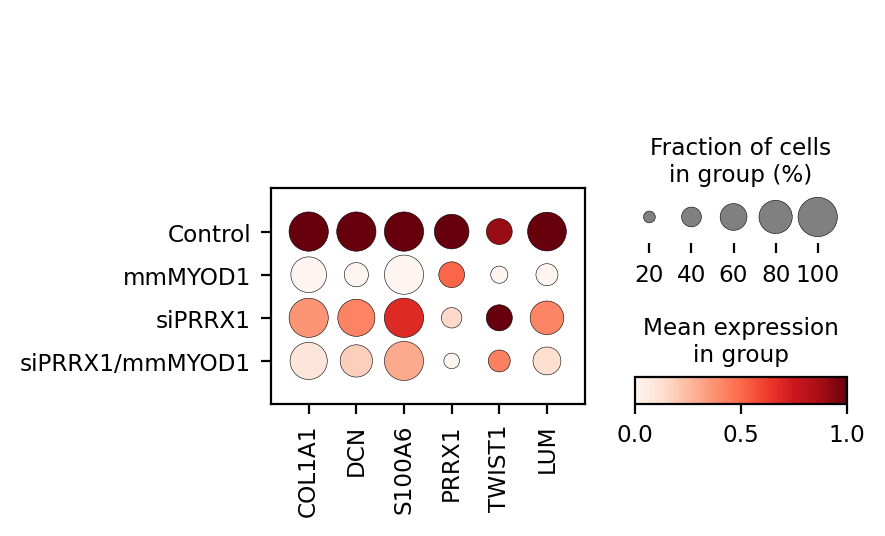

In [27]:
genes_to_plot = [
    'COL1A1', 'DCN', 'S100A6', 'PRRX1', 'TWIST1', 'LUM',
    # 'MYOD1', 'DES', 'MYL9', 'MYLK',
]

plt.rcParams['figure.dpi'] = 200

sc.pl.dotplot(
    adata,
    genes_to_plot,
    groupby='pooled_condition',
    # vmin=0,
    # vmax=6,
    layer='log_norm',
    standard_scale='var',
)

In [4]:
# tmp = adata[adata.obs['pooled_condition'] == 'siPRRX1']

# sc.pl.umap(
#     tmp,
#     color=['MYOD1'],
#     size=40,
#     # mask_obs=['dataset'],
#     add_outline=True,
#     outline_color=('k', 'k'),
#     frameon=False, 
#     ncols=2,
#     alpha=1,
# )

# sc.pl.violin(
#     adata,
#     keys=['MYOD1', 'PRRX1'],
#     groupby='pooled_condition',
#     # layer='log_norm',
# )

In [5]:
# sc.pl.violin(
#     adata,
#     keys=['MYOD1', 'PRRX1'],
#     groupby='pooled_condition',
#     # layer='log_norm',
# )

In [6]:
# scatter plot of PRRX1 vs MYOD1 

In [7]:
# adata.X = adata.layers['raw_counts']

# threshold = 1  # replace with your cutoff

# # Extract MYOD1 expression as a dense 1D array
# myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# # Create a mask for siPRRX1 cells with MYOD1 expression above the threshold
# mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr >= threshold)

# # Count cells
# num_cells = np.sum(mask)

# print(f'Number of siPRRX1 cells with MYOD1 expression above {threshold}: {num_cells}')


# tmp = adata[mask, :].copy()

# sc.pl.violin(
#     tmp,
#     keys=['MYOD1', 'PRRX1']
# )

In [8]:
# tmp.obs[['condition_counts_rate', 'PRRX1-fb_counts']].describe()

In [9]:
# siPRRX1_mask = adata.obs['pooled_condition'] == 'siPRRX1'

# # Extract MYOD1 expression for siPRRX1 cells and convert to dense array
# myod1_expr = adata[siPRRX1_mask, 'MYOD1'].X.toarray().flatten()

# # Plot histogram
# # plt.figure(figsize=(6,4))
# plt.hist(myod1_expr, bins=20, color='skyblue', edgecolor='black')

# plt.show()

In [10]:
# adata.X = adata.layers['raw_counts']

# threshold = 1  # replace with your cutoff

# # Extract MYOD1 expression as a dense 1D array
# myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# # Create a mask for siPRRX1 cells with MYOD1 expression above the threshold
# mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr >= threshold)



# Load in marker genes

### PanglaoDB

In [8]:
### PanglaoDB marker genes
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563


label,Fibroblasts,Myocytes,Myoblasts,Myofibroblasts,Pluripotent Stem Cells
RARRES2,True,False,False,False,False
CELA1,True,False,False,False,False
LUM,True,False,True,True,False
PRRX1,True,True,True,True,False
SCARA5,True,False,False,False,False


In [25]:
hybrid_cells = adata[adata.obs['dataset'] == 'Hybrid']

mean_expr = np.asarray(hybrid_cells.X.mean(axis=0)).flatten()

# Create DataFrame for easy sorting
gene_expression = pd.DataFrame({
    'gene': hybrid_cells.var_names,
    'mean_expression': mean_expr
})

# Sort genes by expression level (descending)
ranked_genes = gene_expression.sort_values(by='mean_expression', ascending=False)
ranked_subset = ranked_genes[ranked_genes['gene'].isin(myoblast)]
ranked_subset.head(50)

,gene,mean_expression
23915,VIM,54.635315
20249,S100A4,28.821066
23096,TPM2,28.814060
16748,NCL,20.412600
23094,TPM1,20.298325
3188,COL1A2,19.502447
17165,NPM1,18.749512
2010,CALD1,18.731659
23360,TSPAN9,15.650602
2150,CAV1,15.420376


In [23]:
myoblast = set(panglao_markers['Myocytes'].index)

myoblast =[gene for gene in myoblast if gene in adata.var_names]
print(myoblast)

['DCN', 'DNMT3B', 'ZNF296', 'FN1', 'PHLDB1', 'SSC5D', 'ANGPT2', 'ACTN2', 'GJA1', 'SGCA', 'DES', 'ACTC1', 'MYH2', 'P4HA1', 'COL4A1', 'COL1A1', 'LUM', 'MFAP5', 'LRRK1', 'CCN4', 'TRIM55', 'SOD3', 'TEK', 'COL6A3', 'SULF1', 'CCL2', 'NES', 'POPDC2', 'BGN', 'NFKB1', 'UNC45B', 'TNNC2', 'RCC2', 'XIRP1', 'COL8A1', 'IGFBP7', 'COL12A1', 'TSPAN9', 'SALL4', 'GPC1', 'FLNC', 'PKDCC', 'FOSB', 'GINS1', 'DLL1', 'RARRES2', 'GSN', 'PALLD', 'RUNX1', 'NBR1', 'SRPX2', 'FAM180A', 'TEAD1', 'FRZB', 'PCSK6', 'GMPS', 'HSPB6', 'KNTC1', 'NR4A2', 'ITGA3', 'C1R', 'HIF1A', 'HCK', 'ENO3', 'LIF', 'PTN', 'MGP', 'RASL12', 'CXCL14', 'DDR2', 'ANGPTL2', 'MFAP4', 'HDAC2', 'PIF1', 'TRIO', 'RND3', 'MRC1', 'VIM', 'FKBP9', 'CHEK1', 'PLPP3', 'SGO1', 'LMOD2', 'FBLN5', 'CMYA5', 'MUSK', 'ACTA2', 'FGR', 'WDHD1', 'FGF2', 'PHF6', 'TAGLN', 'FAM114A1', 'TNNT1', 'ADAMTS10', 'NR2F6', 'LIN28A', 'FABP4', 'NID1', 'COL4A3', 'COL5A3', 'YAP1', 'SGCG', 'FGFR4', 'KLF4', 'NOTCH3', 'SEPHS1', 'MCM10', 'PRKCQ', 'ELN', 'NPPA', 'HRC', 'HELLS', 'PTX3', 'CT

### TFs

In [12]:
### Transcription Factors
tfpath = "../resources/allTFs_hg38.txt"

with open(tfpath, 'r') as file:
    tf_list = [line.strip() for line in file]

print(len(tf_list))

1892


### GO processes

In [45]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2023, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),5S Class rRNA Transcription By RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),7-Methylguanosine mRNA Capping (GO:0006370),...,Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Glucuronidation (GO:0052697),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638),Zymogen Inhibition (GO:0097341)
0,ATIC,SDF2L1,IDH1,UPF1,DAZ4,PAPSS1,GTF3C2,RNGTT,SNRPD3,RNGTT,...,TYW5,GSTM4,UGT2B28,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,FGB,CAST
1,PAICS,HSPA9,PHYH,TRIM71,TIRAP,PAPSS2,GTF3C3,RNMT,SNRPD2,RNMT,...,TYW3,GSTM3,UGT1A6,SLC22A4,SLC22A1,SLC30A7,SLC39A1,SLC39A1,F11,XIAP
2,PFAS,CCT2,GOT2,RC3H1,DAZ3,SULT1A2,GTF3C4,NCBP1,SNRPD1,NCBP1,...,TYW1,GSTM2,UGT2B4,ABCB1,SLC22A2,SLC30A6,SLC30A4,SLC30A9,FGG,CARD18
3,ADSS1,HSPA6,MRPS36,ZFP36L1,YBX3,SULT1C4,GTF3C5,CMTR2,TGS1,CMTR2,...,TRMT12,GSTM1,UGT1A9,ABCC2,ABCC1,SLC30A5,SLC30A3,SLC30A4,BAD,CARD8
4,ADSS2,ST13,GOT1,ZFP36L2,DAZ2,SULT2A1,GTF3C6,RAMAC,SNRPF,RAMAC,...,TYW1B,NR1I2,UGT1A8,SLC15A2,ABCG2,SLC30A2,SLC30A5,SLC30A3,F12,CST7


In [46]:
[col for col in geneset if "tgf" in col.lower()]

[]

In [15]:
# DNA damage genes
damage_terms = [col for col in geneset if "dna damage" in col.lower()]
print(f"N dna damage terms: {len(damage_terms)}")
df = geneset[damage_terms]
damage_genes = list(set(df.stack().tolist()))
print(f"N dna damage genes: {len(damage_genes)}\n")


# Senescence genes
senescence_terms = [col for col in geneset if "senescence" in col.lower()]
print(f"N senescence terms: {len(senescence_terms)}")
df = geneset[senescence_terms]
senescence_genes = list(set(df.stack().tolist()))
print(f"N senescence genes: {len(senescence_genes)}\n")


# Circadian rythym genes
circadian_terms = [col for col in geneset if "circadian" in col.lower()]
print(f"N circadian terms: {len(circadian_terms)}")
df = geneset[circadian_terms]
circadian_genes = list(set(df.stack().tolist()))
print(f"N circadian genes: {len(circadian_genes)}\n")


# Alternative splicing genes
splice_terms = [col for col in geneset if "splice" in col.lower()]
print(f"N AS terms: {len(splice_terms)}")
df = geneset[splice_terms]
splice_genes = list(set(df.stack().tolist()))
print(f"N AS genes: {len(splice_genes)}\n")


# Cell cycle genes
cc_terms = [col for col in geneset if "cell cycle" in col.lower()]
print(f"N cell cycle terms: {len(cc_terms)}")
df = geneset[cc_terms]
cc_genes = list(set(df.stack().tolist()))
print(f"N cell cycle genes: {len(cc_genes)}\n")

N dna damage terms: 26
N dna damage genes: 509

N senescence terms: 4
N senescence genes: 40

N circadian terms: 5
N circadian genes: 44

N AS terms: 14
N AS genes: 277

N cell cycle terms: 44
N cell cycle genes: 826



### Other

In [16]:
### Core reprogramming regulators, cell cycle, and circadian genes from Liu 2018 paper (supplemental table S3, S4)
fpath = "../resources/liu_core_genes.csv"
df = pd.read_csv(fpath)

# core muscle and fibroblast reprogramming regulators
core_regulators = list(set(df[['Fibroblast', 'Muscle']].stack().tolist()))
print(f"N core regulators of MYOD1-mediated reprogramming: {len(core_regulators)}")

# core circadian genes
core_circadian = df['Circadian'].unique()
print(f"N core circadian genes: {len(core_circadian)}")

# combine with GO circadian genes
circadian = list(set(core_circadian) | set(circadian_genes))
print(f"N total circadian genes: {len(circadian)}\n")


### Cell-type specific marker genes from PanglaoDB 2021 and Tabula Sapiens
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)

cells = ['skeletal_muscle', 'myocyte', 'myoblast']
myogenic = mdf[mdf['category'].isin(cells)]['gene_name'].dropna().unique()
print(f"N skeletal muscle/myocyte/myoblast genes: {len(myogenic)}")

fibroblast = mdf[mdf['category'] == 'fibroblast']['gene_name'].dropna().unique()
print(f"N fibroblast genes: {len(fibroblast)}")

myofibroblast = mdf[mdf['category'] == 'myofibroblast']['gene_name'].dropna().unique()
print(f"N myofibroblast genes: {len(myofibroblast)}")

N core regulators of MYOD1-mediated reprogramming: 144
N core circadian genes: 28
N total circadian genes: 63

N skeletal muscle/myocyte/myoblast genes: 455
N fibroblast genes: 461
N myofibroblast genes: 240


In [17]:
### Combine into 1 data object
categories = {
    'TFs': tf_list,
    'Fibroblasts': fibroblast,
    'Myofibroblasts': myofibroblast,
    'Myogenic': myogenic,
    'cell_cycle': cc_genes,
    'AS': splice_genes,
    'Circadian': circadian,
    'Core_reprogramming': core_regulators,
    'Senescence': senescence_genes,
    'DNA_damage': damage_genes,
    
}

for key, gene_list in categories.items():
    adata.uns[key] = gene_list
    print(f"N genes for {key}: {len(gene_list)}")

N genes for TFs: 1892
N genes for Fibroblasts: 461
N genes for Myofibroblasts: 240
N genes for Myogenic: 455
N genes for cell_cycle: 826
N genes for AS: 277
N genes for Circadian: 63
N genes for Core_reprogramming: 144
N genes for Senescence: 40
N genes for DNA_damage: 509


In [52]:
database = "WikiPathways_2024_Human"

library = download_library(database)

library = pd.DataFrame.from_dict(library, orient='index').T
library.head()

,SRF And miRs In Smooth Muscle Differentiation And Proliferation WP1991,TCA Cycle And Deficiency Of Pyruvate Dehydrogenase Complex PDHc WP2453,Mammary Gland Development Pathway Embryonic Development Stg 1/4 WP2813,Initiation Of Transcription And Translation Elongation HIV1 LTR WP3414,Hypothesized Pathways In Pathogenesis Of Cardiovascular Disease WP3668,TGF Beta In Thyroid Cells For Epithelial Mesenchymal Transition WP3859,Development Of Pulmonary Dendritic Cells And Macrophage Subsets WP3892,mRNA Protein And Metabolite Inducation Pathway By Cyclosporin A WP3953,Somatroph Axis GH Relationship To Dietary Restriction And Aging WP4186,Chromosomal And Microsatellite Instability In Colorectal Cancer WP4216,...,Ferroptosis WP4313,IL2 Signaling WP49,Cholestasis WP5238,GPCRs Other WP117,Cori Cycle WP1946,ID Signaling WP53,Cell Cycle WP179,Autophagy WP4923,Apoptosis WP254,Melanoma WP4685
0,MEF2B,FH,TGFB1,CREBBP,SMAD3,SMAD3,BATF3,SLC7A5,AKT1,TGFB1,...,ACSL3,STAT5B,ABCC4,GPR17,G6PD,SREBF1,TGFB1,ATG3,MAP3K1,BAD
1,CAMK2D,IDH1,ITGB1,HEXIM1,POSTN,SMAD2,SPI1,KEAP1,PTEN,RHOA,...,GPX4,MAP2K2,ABCG8,GPR18,TPI1,RB1,TGFB3,ATG9A,JUN,MITF
2,MEF2A,PDHA1,TNF,NFATC4,SMAD2,SMAD4,CSF2,SLC3A2,SIRT1,CSNK1A1,...,ACSL1,STAT1,ABCB4,HTR1F,PGAM1,PAX5,TGFB2,UVRAG,SCAF11,BRAF
3,MEF2D,DLST,NRG3,NFATC3,SMAD4,FN1,CSF1,SLC1A5,MTOR,TGFB3,...,NCOA4,CISH,ABCC2,GPR55,SLC2A1,MYOD1,ZBTB17,WIPI2,APAF1,CDK6
4,MEF2C,CS,SFRP1,NFATC2,ANGPT2,TNC,STAT3,SLC7A11,IGF1R,JUN,...,GSS,MAP2K1,ABCC3,OR1F1,SLC2A2,ELK1,CDC25A,PRKAB1,BAD,PIK3CB


In [59]:
[col for col in library if "fibrotic" in col.lower()]

['Overview Of Proinflammatory And Profibrotic Mediators WP5095']

In [60]:
pathways_of_interest = [
    'TGF Beta Receptor Signaling WP560', 'TGF Beta Signaling Pathway WP366',
    'Hippo Signaling Regulation WP4540', 'Hippo YAP Signaling WP4537', 'Mechanoreg And Pathology Of YAP TAZ Hippo And Non Hippo Mechs WP4534',
    'Overview Of Proinflammatory And Profibrotic Mediators WP5095',
]

wiki = library[pathways_of_interest]
print(wiki.shape)

(507, 6)


In [18]:
# cc_path = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/all_cell_cycle_JC.csv"

# cc = pd.read_csv(cc_path)
# cc = cc.rename(columns={"Unnamed: 0": "gene_name"})
# cc = cc.set_index('gene_name')

# # just extract GO cell cycle genes

# cc = cc[['is_GO']]

# cc = cc[cc.any(axis=1)]

# print(cc.shape)
# cc.head()

# cc = cc.reset_index()

# cc_genes = cc['gene_name'].unique()
# print(len(cc_genes))

# # is_cols = [col for col in cc.columns if col.startswith('is_')]
# # cc = cc[is_cols]
# # print(f"total cc genes: {cc.shape[0]}")

# # cc_filt = cc.drop(columns='is_liu')
# # cc_filt = cc_filt[cc_filt.any(axis=1)]
# # print(f"total genes without Liu: {cc_filt.shape[0]}")

# # cc_filt = cc_filt.reset_index()
# # cc_genes = cc_filt['gene_name'].unique()
# # print(f"Unique cc genes: {len(cc_genes)}")

# # cc_filt.head()

# UMAPs

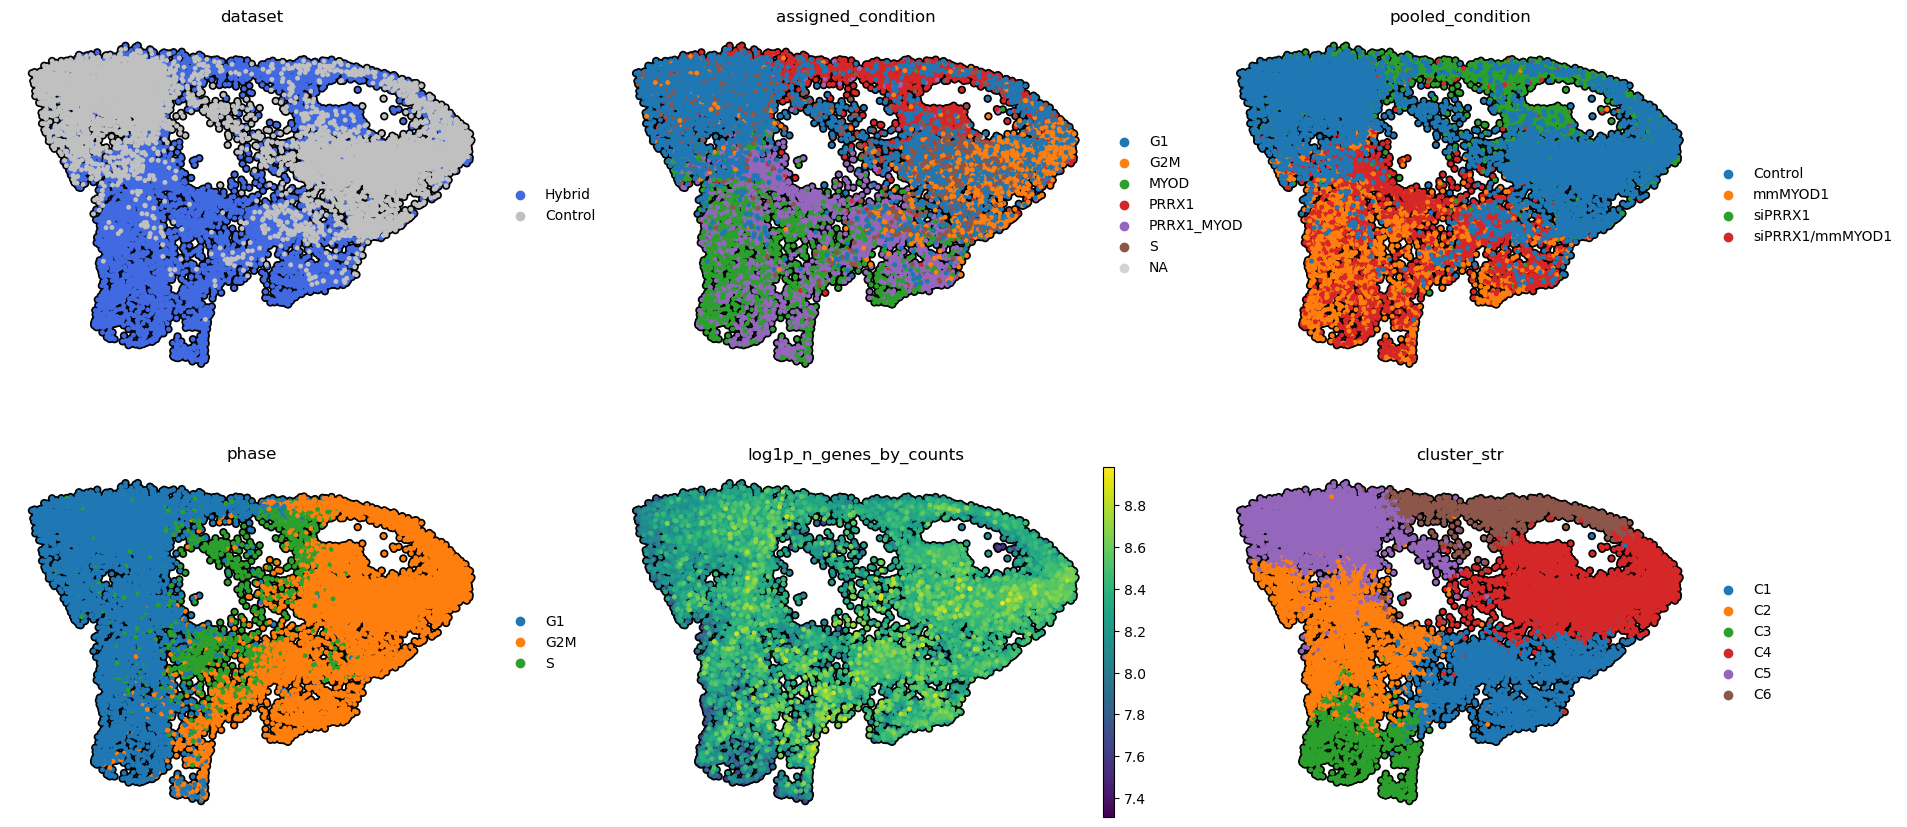

In [19]:
obs_to_plot = ['dataset', 'assigned_condition', 'pooled_condition', 
               'phase', 'log1p_n_genes_by_counts', 'cluster_str']

plt.rcdefaults()
sc.pl.umap(
    adata,
    color=obs_to_plot,
    size=50,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

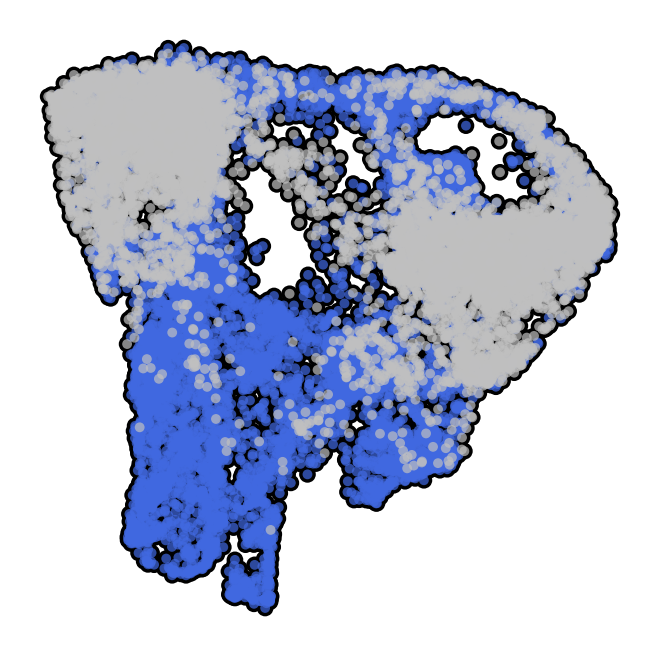

In [20]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

dataset_colors = ["royalblue", "silver"]

sc.pl.umap(
    adata,
    color='dataset',
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    # alpha=0.8,
    title="",
    palette=dataset_colors,
    legend_loc='none',
)

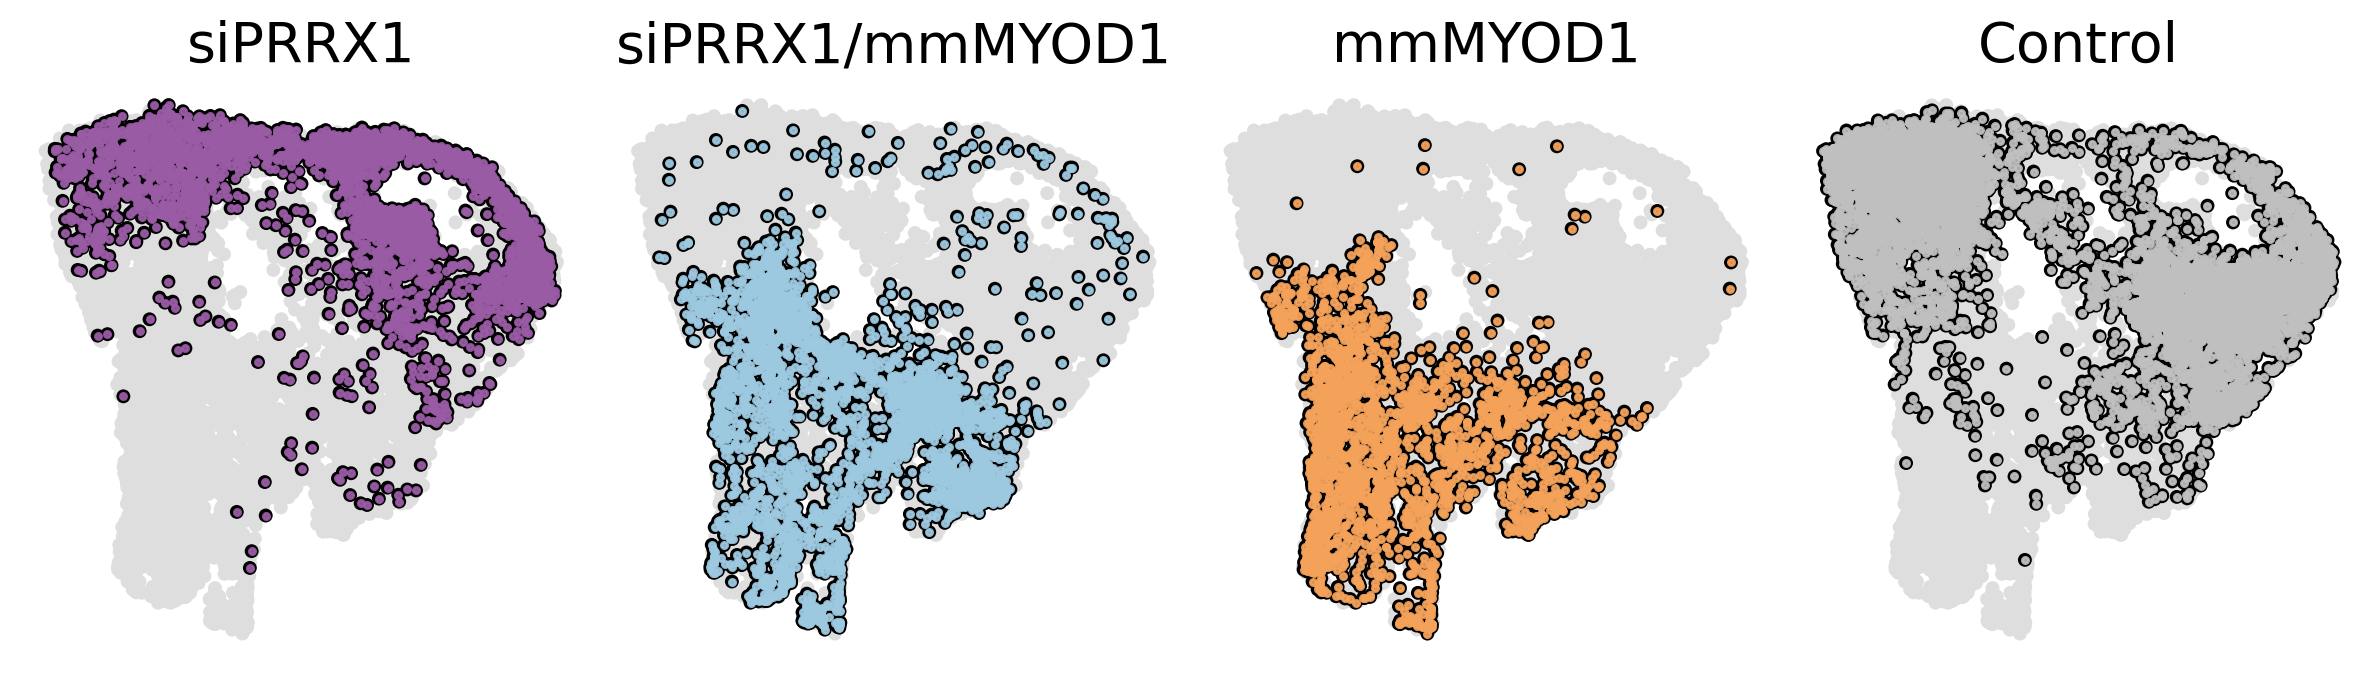

In [21]:
adata.obs['UMAP_1'] = adata.obsm['X_umap'][:, 0] 
adata.obs['UMAP_2'] = adata.obsm['X_umap'][:, 1]

predictions = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1', 'Control']

ncols = 4
nrows = int(np.ceil(len(predictions) / ncols))

plt.rcParams['figure.figsize'] = 12, 3.5
plt.rcParams['figure.dpi'] = 200

fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()

# colors = plt.colormaps['Dark2']
colors = ["#9B5CA6", "#9ECAE1", "#F5A35B", "silver"]

for i, pred in enumerate(predictions):
    ax = axes[i]

    pred_indices = adata.obs['pooled_condition'] == pred

    # Plot background UMAP in grey
    sns.scatterplot(
        data=adata.obs,
        x='UMAP_1',
        y='UMAP_2',
        ec='none',
        s=25,
        color='#DEDEDE',
        ax=ax,
    )

    # Plot only the cells with the current prediction
    ax.scatter(
        adata.obs.loc[pred_indices, 'UMAP_1'],
        adata.obs.loc[pred_indices, 'UMAP_2'],
        c='black',
        s=25,
        alpha=1,
        edgecolors='none',
        linewidths=0,
    )

    
    ax.scatter(
        adata.obs.loc[pred_indices, 'UMAP_1'],
        adata.obs.loc[pred_indices, 'UMAP_2'],
        #c=[colors(i)],
        c=colors[i],
        s=5,
        label=pred,
        alpha=0.9,
        # edgecolors='white',
        # linewidths=0.25,
    )
    
    ax.set_title(pred, fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis(False)

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

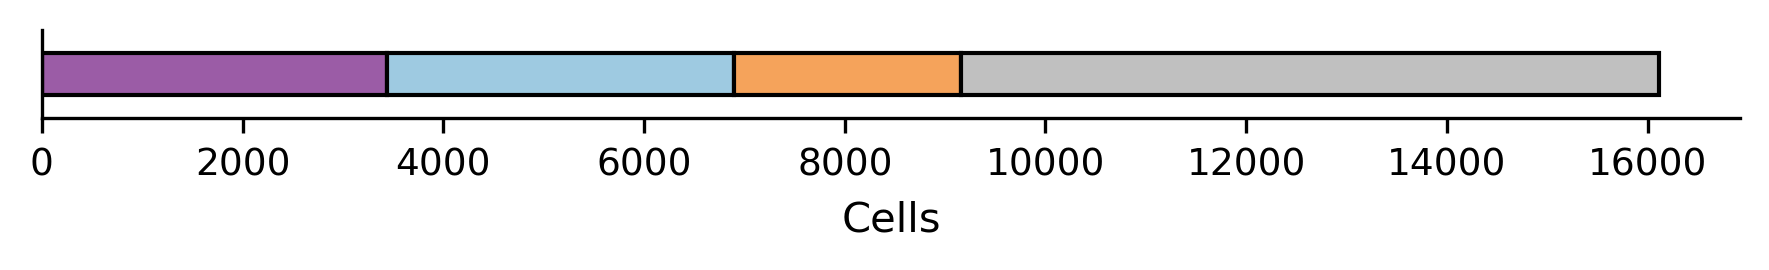

In [22]:
value_counts = adata.obs['pooled_condition'].value_counts()
value_counts = value_counts.rename('Cells')
value_counts = pd.DataFrame(value_counts).T

desired_order = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1', 'Control']  # replace with your actual labels
value_counts = value_counts.reindex(columns=desired_order)

row = value_counts.iloc[0]  # extract the only row as a Series
labels = row.index
values = row.values

cumulative = np.cumsum(np.insert(values, 0, 0))[:-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 1
fig, ax = plt.subplots()

y_pos = 5

# Plot stacked bar
for i in range(len(labels)):
    ax.barh(
        y=1,
        width=values[i],
        left=cumulative[i],
        color=colors[i],
        label=labels[i],
        edgecolor='k',
        linewidth=1.0,
        height=0.95,
    )

ax.set_yticks([])
ax.set_xlabel("Cells")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 2)

plt.xticks(fontsize=9)

plt.tight_layout()
plt.show()

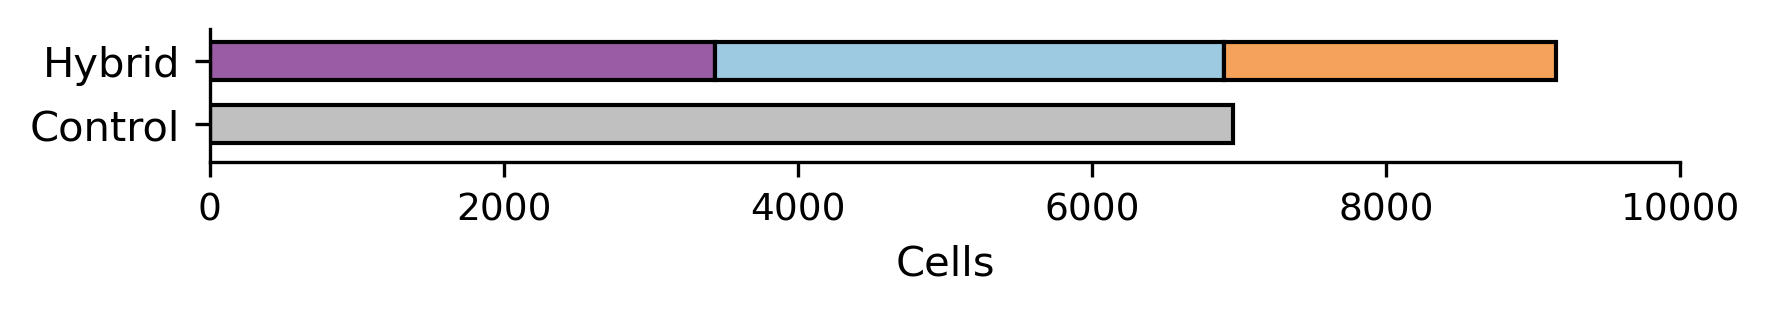

In [23]:
value_counts = adata.obs['pooled_condition'].value_counts()
value_counts = value_counts.rename('Cells')
value_counts = pd.DataFrame(value_counts).T

desired_order = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1', 'Control']  # replace with your actual labels
value_counts = value_counts.reindex(columns=desired_order)

group1_labels = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
group2_label = 'Control'

# Extract counts
group1_counts = value_counts[group1_labels].iloc[0].values
group2_count = value_counts[group2_label].iloc[0]

# Calculate cumulative positions for stacking in group 1
cumulative = np.cumsum(np.insert(group1_counts, 0, 0))[:-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 1.15
fig, ax = plt.subplots()

# Plot stacked bar for group 1
for i in range(len(group1_labels)):
    ax.barh(
        y=1,
        width=group1_counts[i],
        left=cumulative[i],
        color=colors[i],  # Make sure colors are in the correct order
        label=group1_labels[i],
        edgecolor='k',
        linewidth=1.0,
        height=0.6,
    )

# Plot single bar for Control
ax.barh(
    y=0,
    width=group2_count,
    color=colors[-1],  # Assuming the last color is for Control
    label=group2_label,
    edgecolor='k',
    linewidth=1.0,
    height=0.6,
)

# Formatting
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'Hybrid'])
ax.set_xlabel("Cells")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.6, 1.5)
plt.xticks(fontsize=9)
ax.set_xlim(0, 10000)
# plt.legend(fontsize=7, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

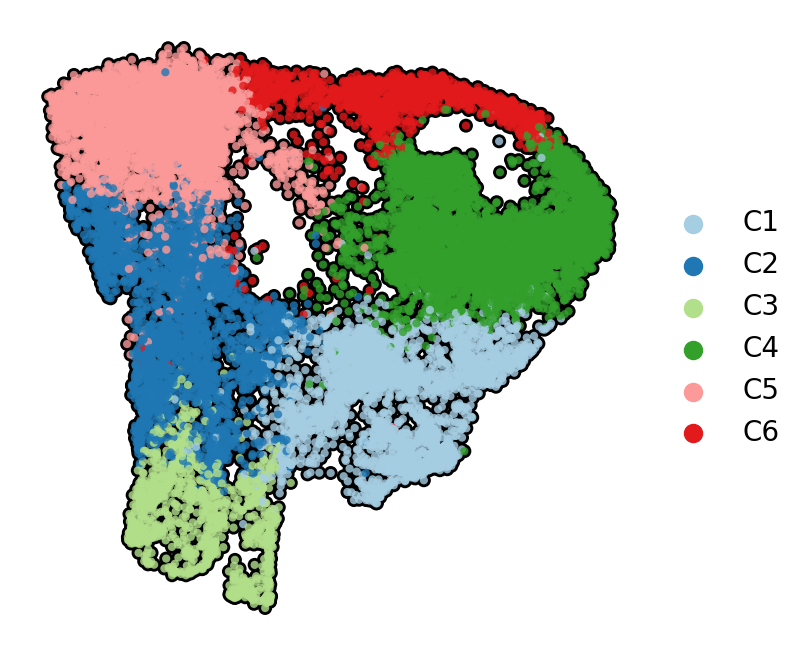

In [13]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

# cluster_colors = sns.color_palette("tab10")
cluster_colors = sns.color_palette("Paired")

sc.pl.umap(
    adata,
    color='cluster_str',
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    title="",
    # palette=
    palette=cluster_colors,
    #legend_loc='none',
)

In [7]:
from matplotlib.colors import to_hex

colorblind_palette = sns.color_palette('colorblind')
hex_codes = [to_hex(color) for color in colorblind_palette]
for hex_code in hex_codes:
    print(hex_code)

#0173b2
#de8f05
#029e73
#d55e00
#cc78bc
#ca9161
#fbafe4
#949494
#ece133
#56b4e9


(16115, 3)


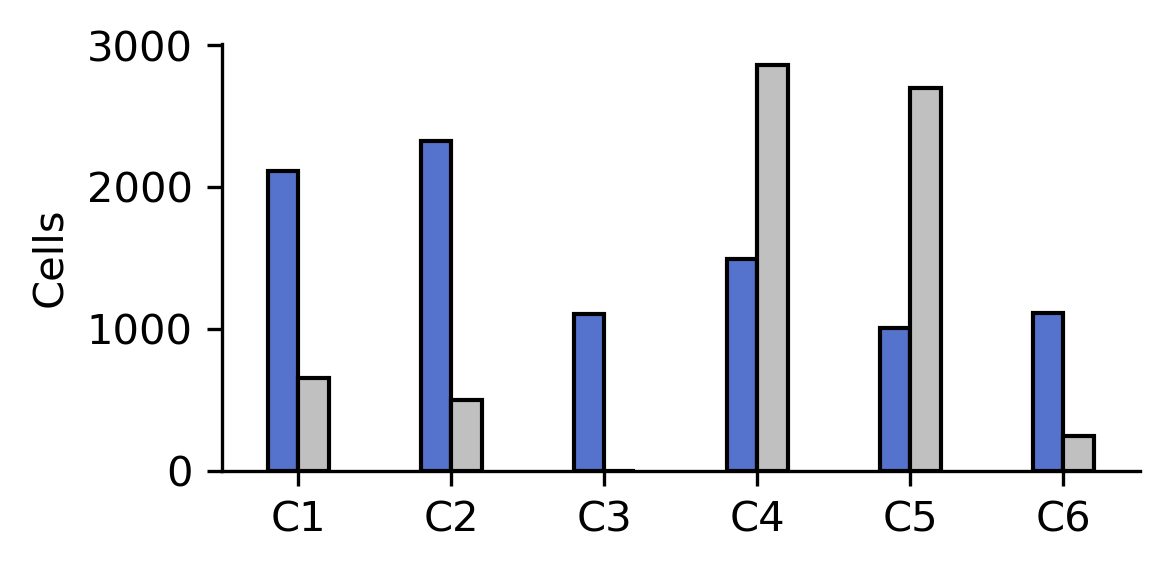

In [25]:
cluster_counts = pd.DataFrame({
    'cell_id': adata.obs.index,
    'cluster_str': adata.obs['cluster_str'].values,
    'dataset': adata.obs['dataset'].values,
})

print(cluster_counts.shape)
cluster_counts.head()

cluster_df = cluster_counts.groupby(['cluster_str', 'dataset'], observed=True).size().reset_index(name='cell_count')

plt.rcParams['figure.figsize'] = 4, 2
plt.rcParams['figure.dpi'] = 300

dataset_colors = ["royalblue", "silver"]

sns.barplot(
    data=cluster_df,
    x='cluster_str',
    y='cell_count',
    hue='dataset',
    width=0.4,
    ec='k',
    legend=False,
    palette=dataset_colors,
)

plt.xlabel("")
plt.ylabel("Cells")

sns.despine()
plt.tight_layout()
plt.show()

In [26]:
color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

plot_order = ["siPRRX1", "siPRRX1/mmMYOD1", "mmMYOD1"]#, "Control"]

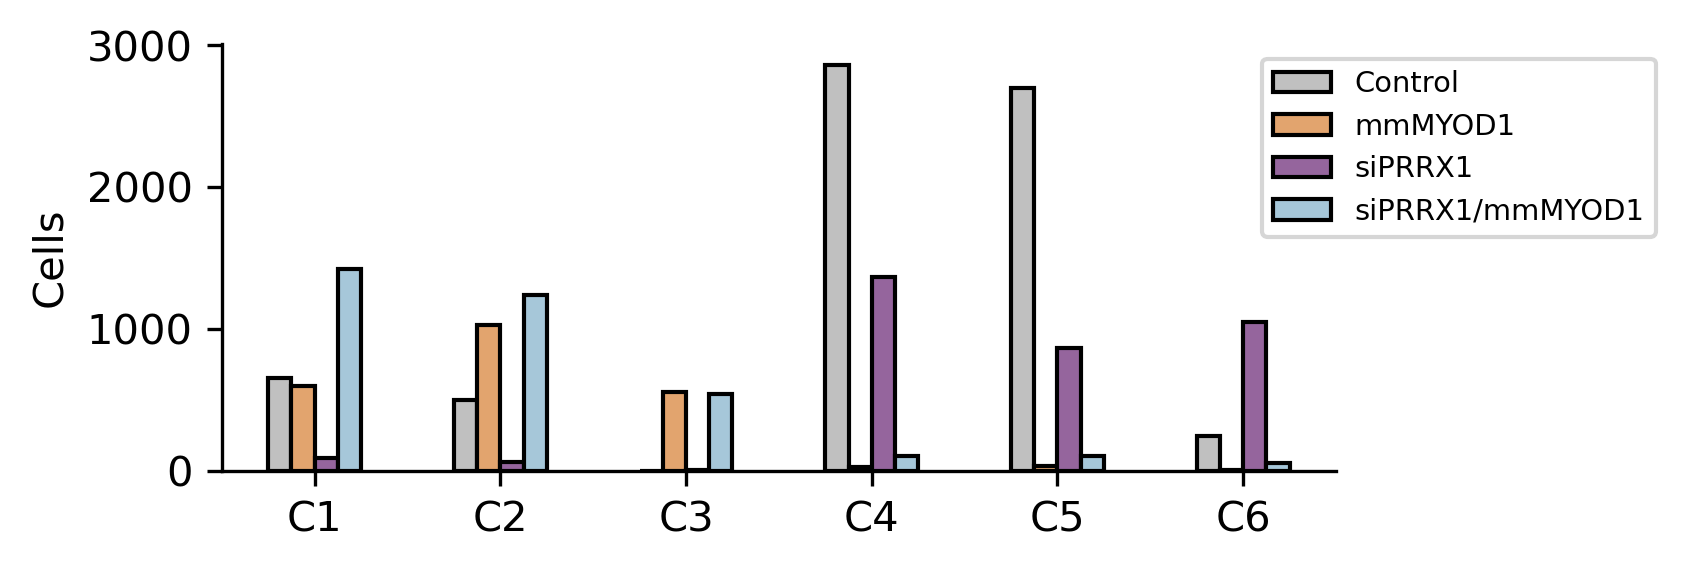

In [27]:
cdf = pd.DataFrame({
    'cell_id': adata.obs_names,
    'cluster_str': adata.obs['cluster_str'],
    'pooled_condition': adata.obs['pooled_condition'],
})

counts = cdf.groupby(['pooled_condition', 'cluster_str'], observed=True).size().reset_index(name='count')
counts.head()

plt.rcParams['figure.figsize'] = 6, 2
plt.rcParams['figure.dpi'] = 300

sns.barplot(
    data=counts,
    x='cluster_str',
    y='count',
    hue='pooled_condition',
    width=0.5,
    ec='k',
    # legend=False,
    palette=color_map,
)

plt.xlabel("")
plt.ylabel("Cells")


plt.legend(bbox_to_anchor=(1.3, 1), loc='upper right', fontsize='x-small')

sns.despine()
plt.tight_layout()
plt.show()

# DGE by condition

In [28]:
# ### Remove siPRRX1 cells with non-zero MYOD1 expression
# adata.X = adata.layers['raw_counts']

# # Extract MYOD1 expression as a dense 1D array
# myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# # Create a mask for siPRRX1 cells with non-zero MYOD1 expression 
# mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)

# cells_to_keep = ~(mask)

# init_cells = adata.n_obs

# adata = adata[cells_to_keep]

# final_cells = adata.n_obs

# print(f"Removed {init_cells - final_cells} siPRRX1 cells with non-zero MYOD1 expression.")
# adata

In [29]:
# # DEGs for each group vs the rest  
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='condition_all',
# )

# DEGs for each HYB group vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

print(deg.shape)
deg.head()

ranking genes
    finished (0:02:09)
(75378, 7)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,mmMYOD1,MT-ND4,71.247650,2.768783,0.0,0.0,0.999113
1,mmMYOD1,MYOD1,66.925995,31.986927,0.0,0.0,0.936170
2,mmMYOD1,LINC-PINT,60.860970,2.704369,0.0,0.0,0.971631
3,mmMYOD1,NAV3,59.871517,3.427659,0.0,0.0,0.922429
4,mmMYOD1,TAF1D,55.939564,2.645126,0.0,0.0,0.956560


In [30]:
# deg.to_csv("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/each_vs_control.csv")
# deg.head()

In [31]:
# tmp = deg[deg['group'] == 'mmMYOD1']

# tmp.to_csv("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/mmMYOD1_vs_control.csv")

# tmp.head()

In [32]:
# # plt.rcdefaults()

# sc.pl.rank_genes_groups_dotplot(
#     adata,
#     key='condition_all',
#     n_genes=5,
#     # values_to_plot='scores',
#     standard_scale='var',
# )

In [33]:
# sc.pl.rank_genes_groups_dotplot(
#     adata,
#     key='condition_all',
#     n_genes=5,
#     values_to_plot='logfoldchanges',
#     standard_scale='var',
# )

In [34]:
# deg = sc.get.rank_genes_groups_df(
#     adata, 
#     group=None,
#     key='condition_vs_control',
# )

# print(deg.shape)
# deg.head()

In [4]:
deg_path = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_condition_vs_control.csv"

deg = pd.read_csv(deg_path)
print(deg.shape)
deg.head()

(75378, 8)


,Unnamed: 0,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,0,mmMYOD1,MT-ND4,71.247650,2.768783,0.0,0.0,0.999113
1,1,mmMYOD1,MYOD1,66.925995,31.986927,0.0,0.0,0.936170
2,2,mmMYOD1,LINC-PINT,60.860970,2.704369,0.0,0.0,0.971631
3,3,mmMYOD1,NAV3,59.871517,3.427659,0.0,0.0,0.922429
4,4,mmMYOD1,TAF1D,55.939564,2.645126,0.0,0.0,0.956560


# Only protein-coding 

In [7]:
sig = deg.copy()

### filter for significant DEGs
pval_cutoff = 0.01       # p-value threshold
logfc_cutoff = 0.5       # log fold change threshold

print("Filtering for significant DEGs...")
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

sig['abs_lfc'] = sig['logfoldchanges'].apply('abs')

sig = sig[(sig['abs_lfc'] > logfc_cutoff) & (sig['pvals_adj'] < pval_cutoff)]
print(f"N unique significant DEGs: {sig['names'].nunique()}\n")


### filter for protein-coding genes
# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

print("Removing non protein-coding, unnamed, and mitochondrial genes...")

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['ribo']] # remove ribosomal genes

print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}\n")

pct_threshold = 0.5
print(f"Filtering for genes exressed in at least {pct_threshold*100}% of the group...")
pdf = pdf[pdf['pct_nz_group'] > pct_threshold] 

print(f"Final N unique genes: {pdf['names'].nunique()}")

pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])
pdf.groupby('group', observed=True)[['group', 'names', 'logfoldchanges']].head(3)

Filtering for significant DEGs...
Using p-value cutoff: 0.01 and log fold change cutoff: 0.5
N unique significant DEGs: 8976

Removing non protein-coding, unnamed, and mitochondrial genes...
N unique DE protein-coding genes: 7429

Filtering for genes exressed in at least 50.0% of the group...
Final N unique genes: 1889


,group,names,logfoldchanges
1,mmMYOD1,MYOD1,31.986927
56,mmMYOD1,ESR1,8.198524
71,mmMYOD1,DPF3,4.407542
7030,siPRRX1,H1-3,3.721858
6986,siPRRX1,H1-4,3.369567
7031,siPRRX1,ZSCAN30,3.345283
12283,siPRRX1/mmMYOD1,MYOD1,30.813738
12299,siPRRX1/mmMYOD1,OASL,3.541403
12355,siPRRX1/mmMYOD1,HAS2,3.510276


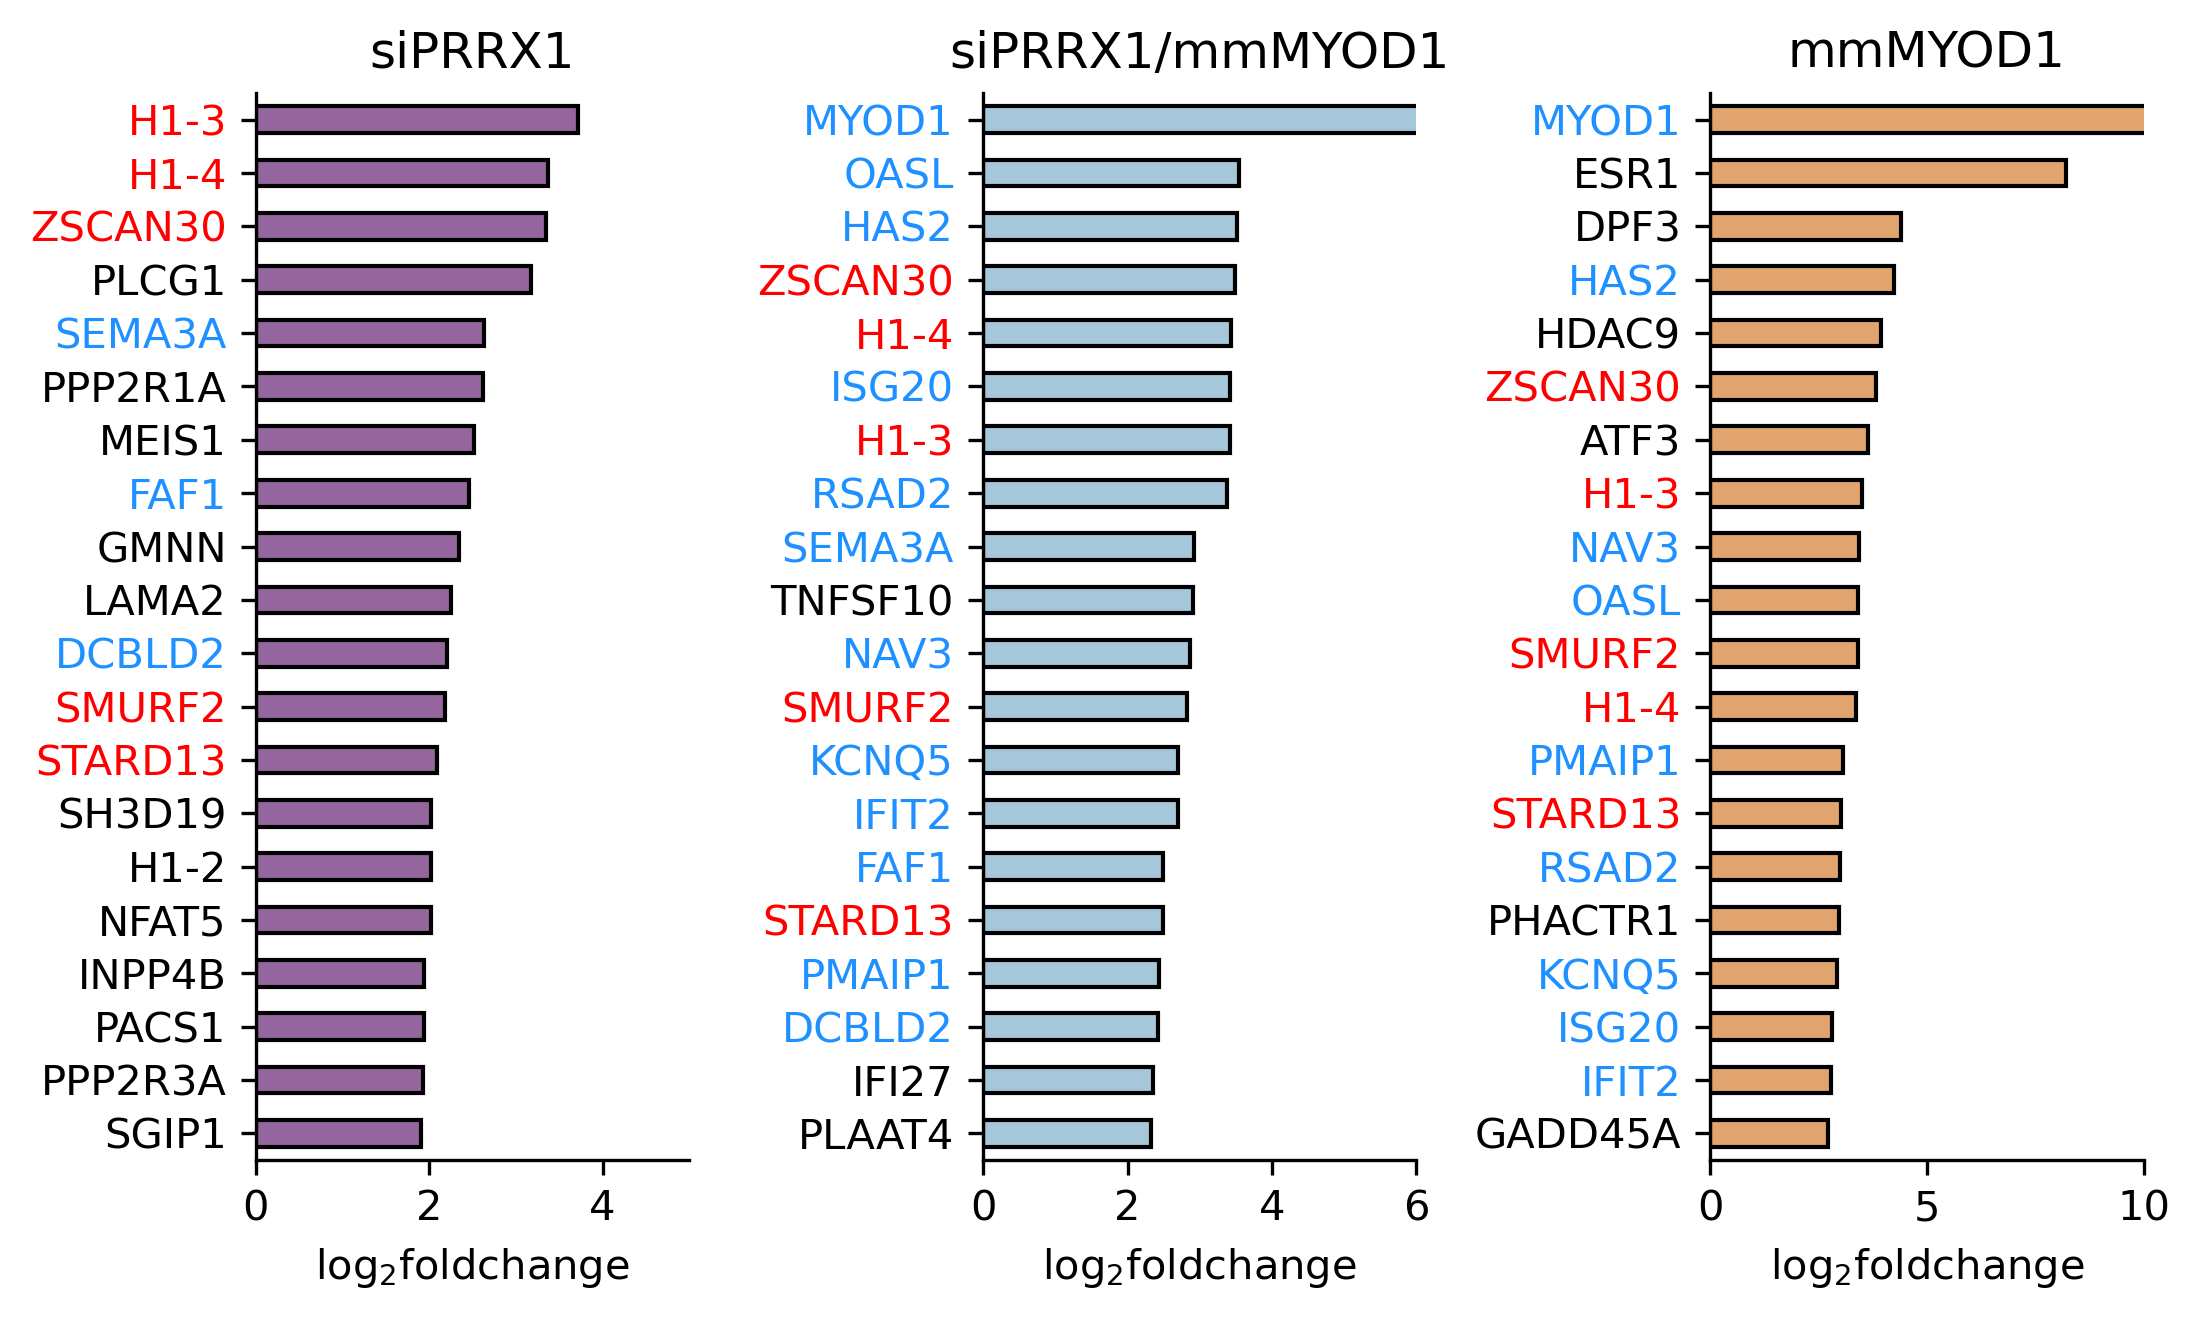

In [36]:
from collections import Counter

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20


top_genes_per_group = {}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

    if group == 'mmMYOD1':
        ax.set_xlim([0, 10])
        # ax.set_xscale('log')
    elif group == 'siPRRX1/mmMYOD1':
        ax.set_xlim([0, 6])
        # ax.set_xscale('log')
    else:
        ax.set_xlim([0, 5])

    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

In [118]:
def pathways_with_genes(gene_list, file_path="../resources/GO_Biological_Process_2023.txt"):
    """
    Returns all pathways where every gene in `gene_list` is present in that pathway's gene set.
    """
    results = []
    genes_set = set(gene_list)
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway = parts[0]
            # Genes start after two tab columns
            pathway_genes = set([x for x in parts[2:] if x])
            if genes_set.issubset(pathway_genes):
                results.append(pathway)
    return results

gene = ['PSMA6']

genes = pathways_with_genes(gene)
print(f"Total pathways: {len(genes)}")
print(f"\nFirst 10 pathways containing gene {gene}:")
print(genes[:10])

Total pathways: 11

First 10 pathways containing gene ['PSMA6']:
['Positive Regulation Of DNA-binding Transcription Factor Activity (GO:0051091)', 'Positive Regulation Of NF-kappaB Transcription Factor Activity (GO:0051092)', 'Proteasomal Protein Catabolic Process (GO:0010498)', 'Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161)', 'Protein Catabolic Process (GO:0030163)', 'Proteolysis (GO:0006508)', 'Proteolysis Involved In Protein Catabolic Process (GO:0051603)', 'Regulation Of Defense Response (GO:0031347)', 'Regulation Of Inflammatory Response (GO:0050727)', 'Regulation Of Response To External Stimulus (GO:0032101)']


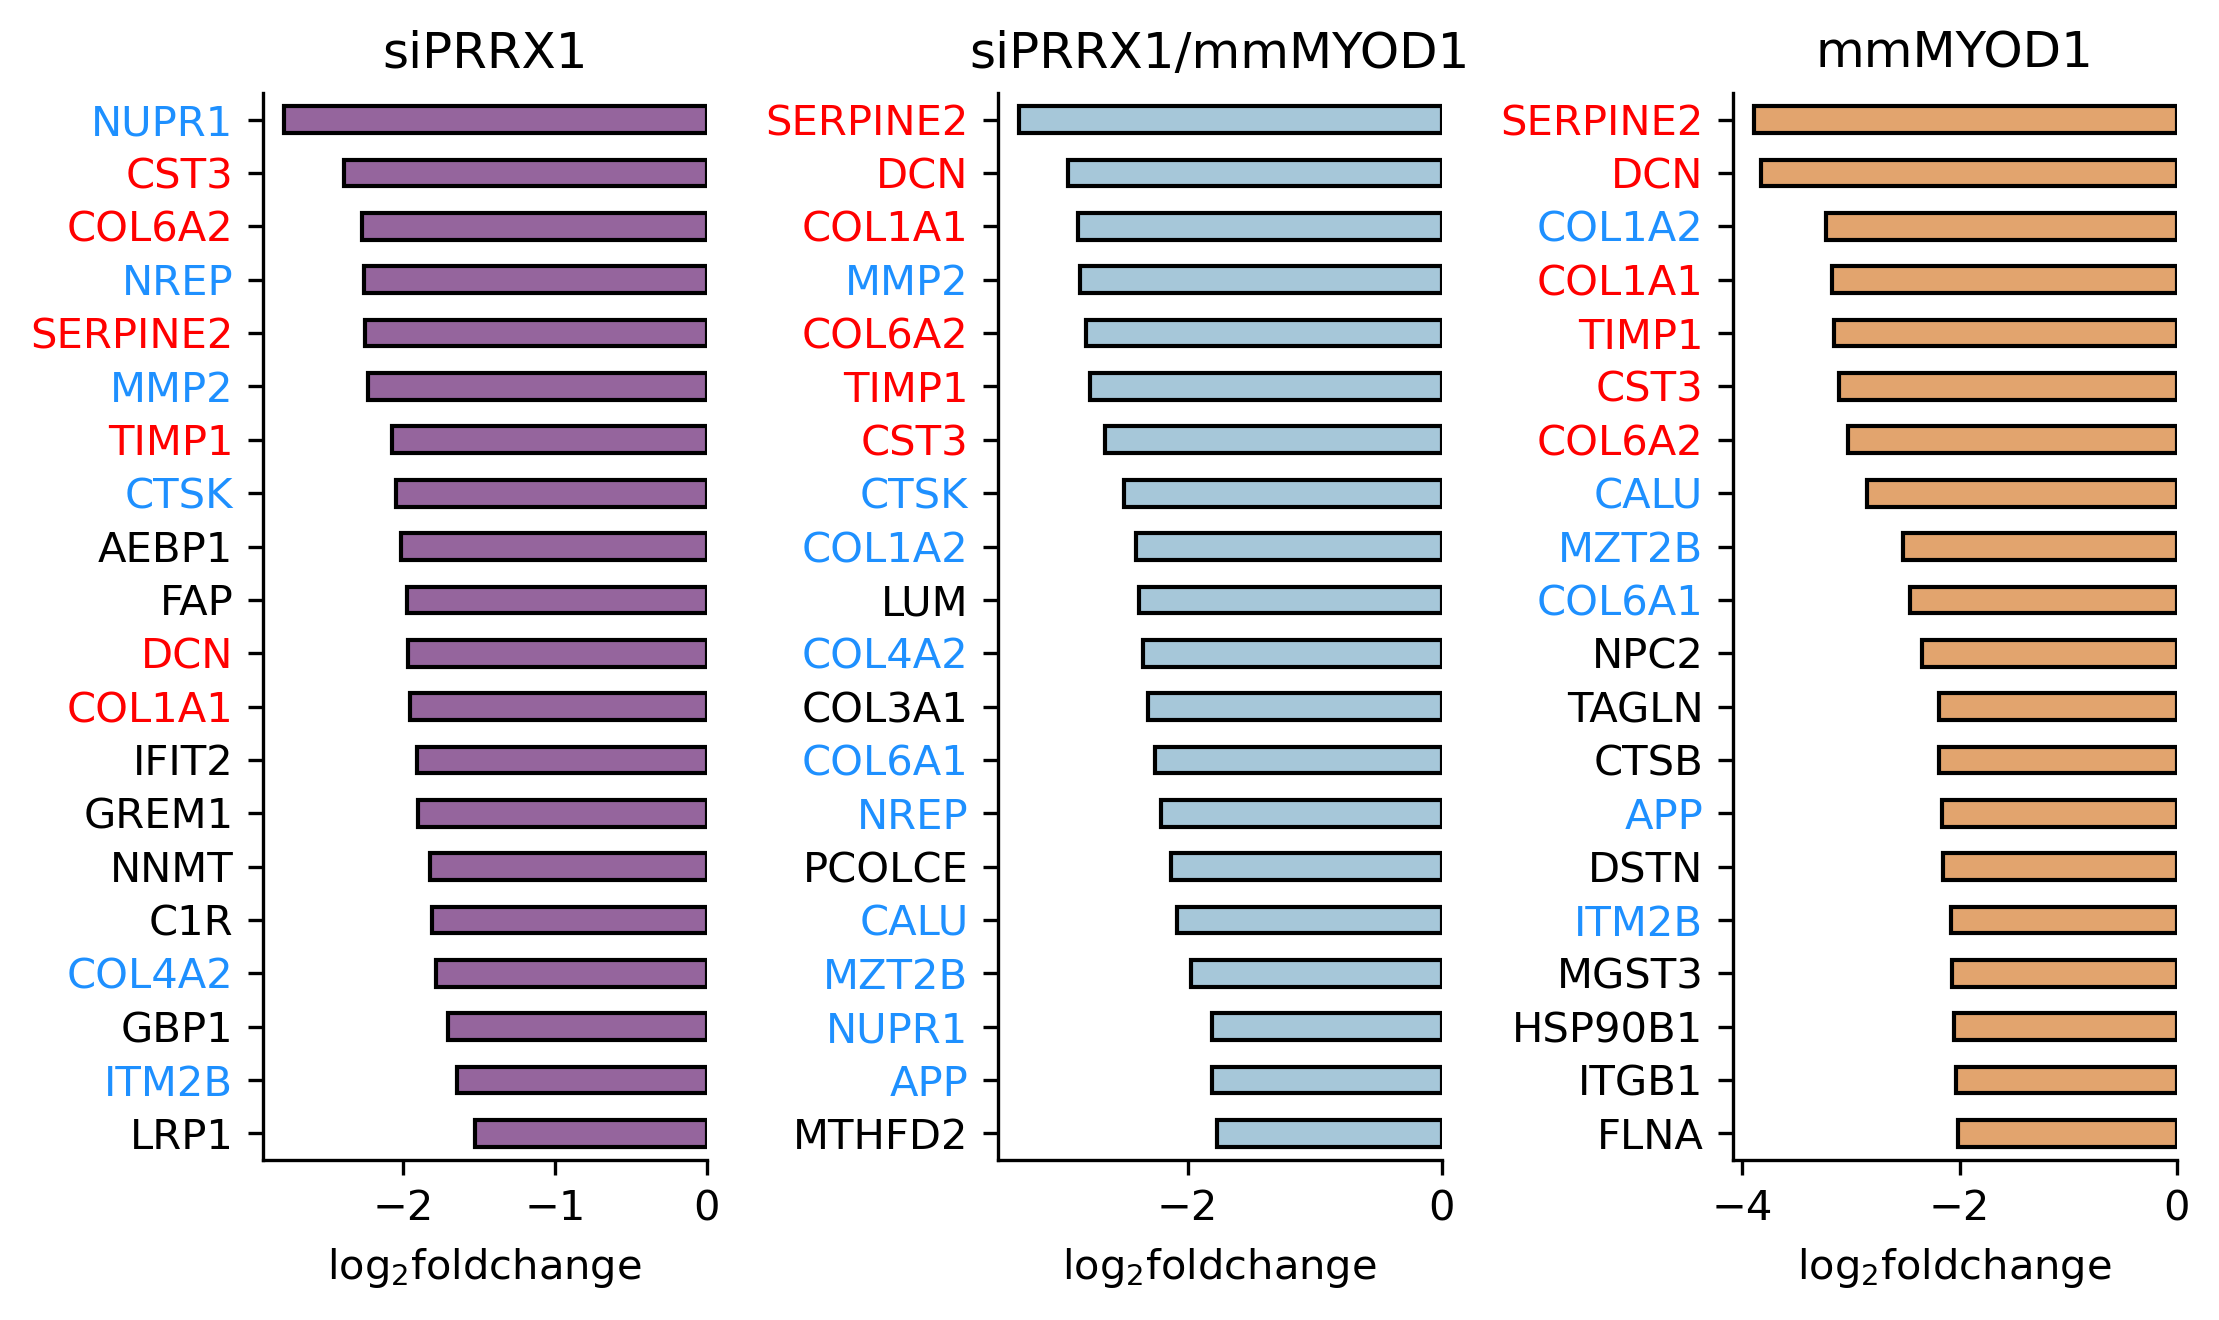

In [37]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20


top_genes_per_group = {}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

    # if group == 'mmMYOD1':
    #     ax.set_xlim([0, 10])
    #     # ax.set_xscale('log')
    # elif group == 'siPRRX1/mmMYOD1':
    #     ax.set_xlim([0, 6])
    #     # ax.set_xscale('log')
    # else:
    #     ax.set_xlim([0, 5])

    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

In [40]:
pdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
1,mmMYOD1,MYOD1,66.925995,31.986927,0.000000e+00,0.000000e+00,0.936170,31.986927,protein_coding,False,False
56,mmMYOD1,ESR1,37.710102,8.198524,0.000000e+00,0.000000e+00,0.530142,8.198524,protein_coding,False,False
71,mmMYOD1,DPF3,35.857616,4.407542,1.399199e-281,1.278410e-279,0.548316,4.407542,protein_coding,False,False
40,mmMYOD1,HAS2,40.500904,4.232737,0.000000e+00,0.000000e+00,0.633422,4.232737,protein_coding,False,False
84,mmMYOD1,HDAC9,34.441345,3.932225,6.068496e-260,5.099567e-258,0.549645,3.932225,protein_coding,False,False


In [143]:
df_up = pdf[pdf['logfoldchanges'] > 0].copy()

# 2. Get top 50 genes per group
df_up['rank'] = (
    df_up.groupby('group')['logfoldchanges']
    .rank(method='first', ascending=False)
)

top50 = df_up[df_up['rank'] <= 50].copy()

# 3. Sort by rank and reshape
top50_sorted = top50.sort_values(['group', 'rank'])

# 4. Pivot so each group is a column of ranked gene names
result = (
    top50_sorted
    .pivot(index='rank', columns='group', values='names')
    .sort_index()
    .reset_index(drop=True)
)


result.to_csv("tables/top50_UPdegs_per_group.csv")
result.head()

group,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1
0,MYOD1,H1-3,MYOD1
1,ESR1,H1-4,OASL
2,DPF3,ZSCAN30,HAS2
3,HAS2,PLCG1,ZSCAN30
4,HDAC9,SEMA3A,H1-4


In [145]:
df_down = pdf[pdf['logfoldchanges'] < 0].copy()

# 2. Get top 50 genes per group
df_down['rank'] = (
    df_down.groupby('group')['logfoldchanges']
    .rank(method='first', ascending=True)
)

top50 = df_down[df_down['rank'] <= 50].copy()

# 3. Sort by rank and reshape
top50_sorted = top50.sort_values(['group', 'rank'])

# 4. Pivot so each group is a column of ranked gene names
result = (
    top50_sorted
    .pivot(index='rank', columns='group', values='names')
    .sort_index()
    .reset_index(drop=True)
)


result.to_csv("tables/top50_DOWNdegs_per_group.csv")
result.head()

group,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1
0,SERPINE2,NUPR1,SERPINE2
1,DCN,CST3,DCN
2,COL1A2,COL6A2,COL1A1
3,COL1A1,NREP,MMP2
4,TIMP1,SERPINE2,COL6A2


In [131]:

top_genes = pdf.groupby('group')['names'].apply(list).apply(pd.Series).T

top_genes = top_genes.head(20)

top_genes

group,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1
0,MYOD1,H1-3,MYOD1
1,ESR1,H1-4,OASL
2,DPF3,ZSCAN30,HAS2
3,HAS2,PLCG1,ZSCAN30
4,HDAC9,SEMA3A,H1-4
5,ZSCAN30,PPP2R1A,ISG20
6,ATF3,MEIS1,H1-3
7,H1-3,FAF1,RSAD2
8,NAV3,GMNN,SEMA3A
9,OASL,LAMA2,TNFSF10


In [136]:
group = 'mmMYOD1'

gene_list = top_genes['mmMYOD1'].tolist()

database="GO_Biological_Process_2023"

enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=database,
        organism='human', 
        outdir=None, 
    )

edf = enr.results.copy()

edf.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Defense Response To Symbiont (GO:0140546),5/148,2.939141e-07,0.000096,0,0,46.240093,695.450006,ISG20;RSAD2;PMAIP1;IFIT2;OASL
1,GO_Biological_Process_2023,Defense Response To Virus (GO:0051607),5/189,9.874861e-07,0.000162,0,0,35.862319,495.907853,ISG20;RSAD2;PMAIP1;IFIT2;OASL
2,GO_Biological_Process_2023,Negative Regulation Of Viral Genome Replicatio...,3/53,1.940242e-05,0.001631,0,0,70.341176,763.209680,ISG20;RSAD2;OASL
3,GO_Biological_Process_2023,Regulation Of Skeletal Muscle Fiber Developmen...,2/7,1.989010e-05,0.001631,0,0,443.888889,4805.225246,MYOD1;HDAC9
4,GO_Biological_Process_2023,Negative Regulation Of Viral Process (GO:0048525),3/61,2.965691e-05,0.001945,0,0,60.614604,631.956671,ISG20;RSAD2;OASL
5,GO_Biological_Process_2023,Regulation Of Viral Genome Replication (GO:004...,3/67,3.932461e-05,0.002150,0,0,54.915441,557.043561,ISG20;RSAD2;OASL
6,GO_Biological_Process_2023,Cellular Response To Estradiol Stimulus (GO:00...,2/20,1.785635e-04,0.008087,0,0,123.222222,1063.477584,MYOD1;ESR1
7,GO_Biological_Process_2023,Negative Regulation Of Interleukin-2 Productio...,2/21,1.972414e-04,0.008087,0,0,116.730994,995.841692,NAV3;HDAC9
8,GO_Biological_Process_2023,Regulation Of Muscle Cell Differentiation (GO:...,2/24,2.587661e-04,0.009431,0,0,100.797980,832.549579,MYOD1;HDAC9
9,GO_Biological_Process_2023,Regulation Of Cell Migration Involved In Sprou...,2/30,4.063745e-04,0.012423,0,0,79.174603,618.213948,STARD13;HDAC9


# GSEA

Running Enrichment on mmMYOD1 group with 500 upregulated genes using database: MSigDB_Hallmark_2020...
Significant terms for mmMYOD1: 13
(alpha = 0.01)


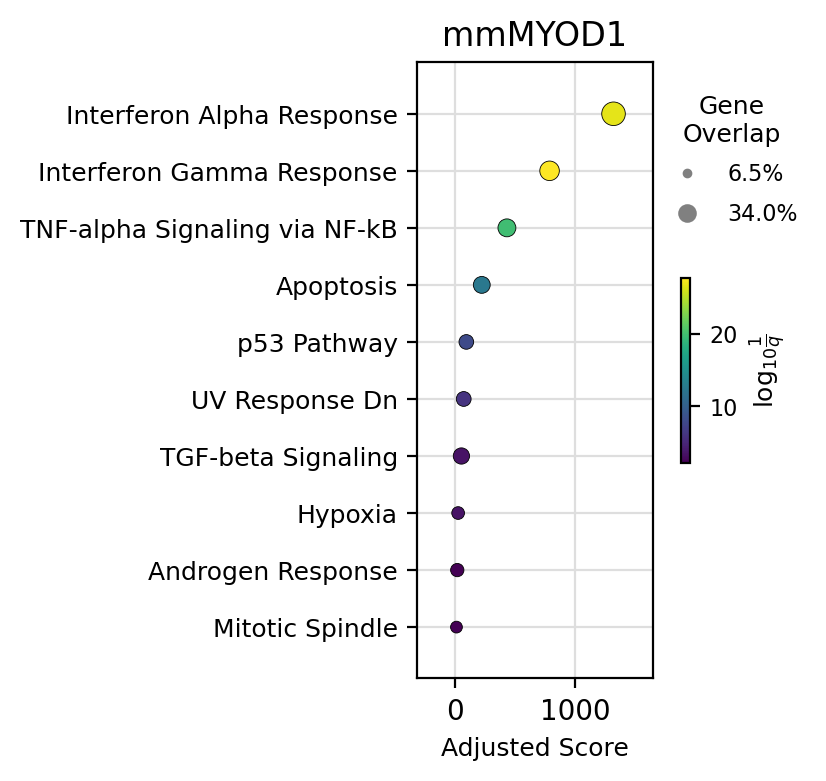

Running Enrichment on siPRRX1 group with 500 upregulated genes using database: MSigDB_Hallmark_2020...
Significant terms for siPRRX1: 8
(alpha = 0.01)


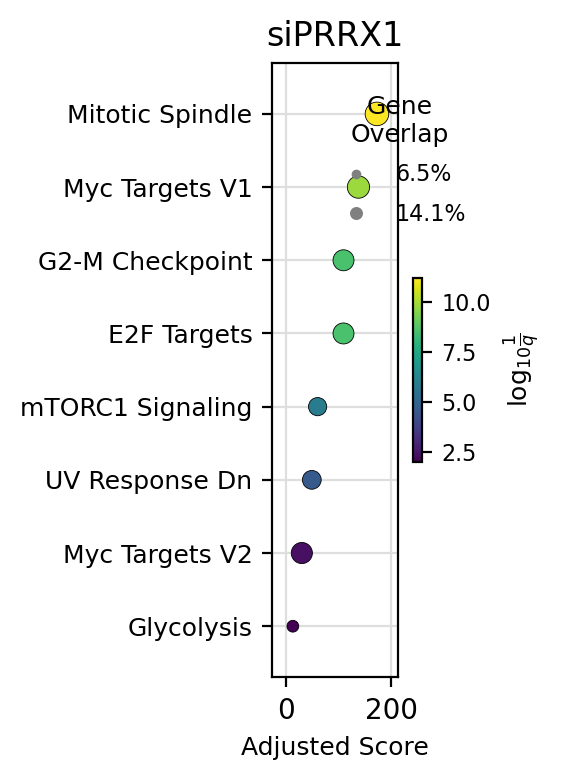

Running Enrichment on siPRRX1/mmMYOD1 group with 500 upregulated genes using database: MSigDB_Hallmark_2020...
Significant terms for siPRRX1/mmMYOD1: 9
(alpha = 0.01)


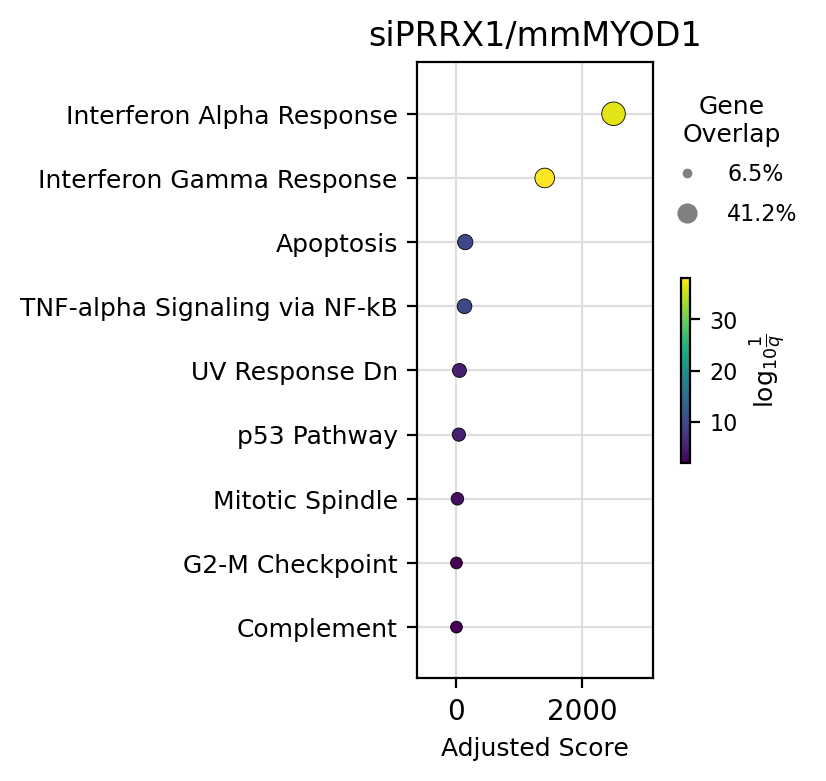

In [47]:
conditions_to_plot = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

n_genes = 500 
# database="GO_Biological_Process_2023"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database = "WikiPathways_2024_Human"
# database='GO_Molecular_Function_2025'
database='MSigDB_Hallmark_2020' 

n_terms = 10
alpha = 0.01

direction = 'upregulated'

if direction == 'upregulated':
    pdf1 = pdf[pdf['logfoldchanges'] > 0]
else:
    pdf1 = pdf[pdf['logfoldchanges'] < 0]


for condition in conditions_to_plot:
    print(f"Running Enrichment on {condition} group with {n_genes} {direction} genes using database: {database}...")

    tmp = pdf1[pdf1['group'] == condition] # get genes specific to condition
    
    if direction == 'upregulated': # sort by logfoldchange
        tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    else:
        tmp = tmp.sort_values(by='logfoldchanges', ascending=True)
    
    # tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    
    gene_list = tmp['names'].head(n_genes).to_list()

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=database,
        organism='human', 
        outdir=None, 
    )
    
    edf = enr.results.copy()


    # Filter for significant terms
    if not edf.empty:
        edf = edf[edf['Adjusted P-value'] < alpha].copy()
        print(f"Significant terms for {condition}: {edf['Term'].nunique()}\n(alpha = {alpha})")

        if edf.empty:
            print(f"No significant terms found for condition: {condition}. Skipping plot.")
            continue 

        overlap_split = edf["Overlap"].str.split("/", expand=True).astype(int)
        edf['Overlap_pct'] = (100 * overlap_split[0] / overlap_split[1]).round(1)
        edf['log10_adj_pval'] = np.log10(1 / edf['Adjusted P-value'])
        # Remove (GO:...) and (Reactome:...) identifiers from term names
        edf['Term'] = edf['Term'].str.replace(r'\s\(GO:\d+\)', '', regex=True)
        edf['Term'] = edf['Term'].str.replace(r'\s\(Reactome:R-HSA-\d+\)', '', regex=True)

     
        edf['adj_score'] = -np.log(edf['Adjusted P-value']) * edf['Odds Ratio'] # Calculate combined score with adjusted p-val
        edf = edf.sort_values(by='Adjusted P-value', ascending=True).head(n_terms).copy() # Get top n terms sorted by significance (Adjusted P-value)
        edf = edf.sort_values(by='adj_score', ascending=False).copy() # Sort by adjusted combined score for plotting (descending)

        plt.rcParams['figure.dpi'] = 200
        fig, ax = plt.subplots(figsize=(2, 4))

        sns.scatterplot(
            data=edf,
            x='adj_score',
            y='Term',
            ec='k', 
            linewidth=0.3,
            hue='log10_adj_pval', 
            palette='viridis', 
            size='Overlap_pct', 
            zorder=3, 
            ax=ax 
        )

        x_margin = 0.25
        y_margin = 0.1
        ax.margins(x=x_margin, y=y_margin)

        ax.grid(
            True,
            c='#DEDEDE', # Grid color
            zorder=0, # Ensures grid is behind scatter points
        )

        # Remove y-axis label
        ax.set_ylabel("")

        # --- Y-tick label wrapping ---
        original_ylabels = edf['Term'].to_list()
        wrap_width = 60 # Adjust this width as needed for your plot size and text length
        wrapped_ylabels = [textwrap.fill(label, wrap_width) for label in original_ylabels]
        ax.set_yticklabels(wrapped_ylabels, fontsize=9)
        # --- End of Y-tick label wrapping ---

        # Colorbar for log10_adj_pval
        norm = plt.Normalize(edf['log10_adj_pval'].min(), edf['log10_adj_pval'].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])
        # `fig.colorbar` is used with `ax` to attach it to the current axes' figure
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.09, shrink=0.3)
        cbar.set_label('log$_{10} \\frac{1}{q}$', fontsize='9')
        cbar.ax.tick_params(labelsize=8)

        # Overlap percentage legend
        min_overlap = edf['Overlap_pct'].min()
        max_overlap = edf['Overlap_pct'].max()

        # Scaling for legend handles to match scatterplot point sizes
        scaled_min_size = min_overlap * 3 # Adjust multiplier (3) to match visual size
        scaled_max_size = max_overlap * 3 # Adjust multiplier (3) to match visual size

        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{min_overlap:.1f}%',
                       markersize=np.sqrt(scaled_min_size / np.pi), linestyle=''),
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{max_overlap:.1f}%',
                       markersize=np.sqrt(scaled_max_size / np.pi), linestyle='')
        ]

        # Gene Overlap legend setup
        legend = ax.legend(handles=legend_handles, title='Gene\nOverlap',
                            loc='upper right', # Location of the legend
                            bbox_to_anchor=(1.7, 0.98), # Position relative to the axes (adjusted for space)
                            fontsize=8, title_fontsize=9, frameon=False, labelspacing=0.75)


        legend_title = legend.get_title()
        legend_title.set_ha('center')

        # Set x-axis label and ticks
        ax.set_xlabel("Adjusted Score", fontsize=9)
        # Ensure x-ticks are consistently formatted
        # ax.set_xticks(ax.get_xticks())
        # ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=8)

        ax.set_title(f"{condition}")

        # Adjust layout to prevent elements from overlapping
        # Rect parameter [left, bottom, right, top] in figure coordinates
        # Adjust 'right' (1.4 here) if legend is still cut off or too far
        plt.tight_layout(rect=[0, 0, 1.4, 1])
        plt.show()

In [45]:
# up = pdf[pdf['logfoldchanges'] > 0]
# print(f"N unique upregulated genes: {up['names'].nunique()}")

# down = pdf[pdf['logfoldchanges'] < 0]
# print(f"N unique downregulated genes: {down['names'].nunique()}\n")

# for group in pdf['group'].unique():

#         tmp = up[up['group'] == group]
#         tmp = tmp[tmp['names'].isin(ipsc_genes)]
        
#         print(f"N upregulated marker genes for {group}: {tmp['names'].nunique()}")
        
#         tmp1 = down[down['group'] == group]
#         tmp1 = tmp1[tmp1['names'].isin(ipsc_genes)]
        
#         print(f"N downregulated marker genes for {group}: {tmp1['names'].nunique()}\n")

In [ ]:
# from upsetplot import from_contents, UpSet

In [ ]:
# n_genes = 200

# top_genes_per_group = (
#     pdf.sort_values(['group', 'logfoldchanges'], ascending=[True, False])
#        .groupby('group')
#        .head(n_genes)
# )

# de_gene_sets = top_genes_per_group.groupby('group', observed=True)['names'].apply(set).to_dict()

In [ ]:
# from upsetplot import plot

# de_gene_sets = pdf.sort_values(['group', 'logfoldchanges'], ascending=[True, False]).groupby('group', observed=True)['names'].apply(set).to_dict()

# upset_data = from_contents(de_gene_sets)

# plot(upset_data, show_counts='%d')
# plt.show()

In [ ]:
# pdf = pdf.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

# siPRRX1_genes = set(pdf[pdf['group'] == 'siPRRX1']['names'])
# mmMYOD1_genes = set(pdf[pdf['group'] == 'mmMYOD1']['names'])
# siPRRX1_mmMYOD1_genes = set(pdf[pdf['group'] == 'siPRRX1/mmMYOD1']['names'])

# ordered_conditions = [
#     'Unique siPRRX1',
#     'Unique siPRRX1/mmMYOD1',
#     'Unique mmMYOD1',
#     'siPRRX1 & siPRRX1/mmMYOD1 (Only)',
#     'siPRRX1 & mmMYOD1 (Only)',
#     'mmMYOD1 & siPRRX1/mmMYOD1 (Only)',
#     'All Three Overlap'
# ]

# data = {
#     'Condition': ordered_conditions,
#     'Gene Count': [
#         len(siPRRX1_genes - mmMYOD1_genes - siPRRX1_mmMYOD1_genes),
#         len(siPRRX1_mmMYOD1_genes - siPRRX1_genes - mmMYOD1_genes),
#         len(mmMYOD1_genes - siPRRX1_genes - siPRRX1_mmMYOD1_genes),
#         len((siPRRX1_genes.intersection(siPRRX1_mmMYOD1_genes)) - mmMYOD1_genes),
#         len((siPRRX1_genes.intersection(mmMYOD1_genes)) - siPRRX1_mmMYOD1_genes),
#         len((mmMYOD1_genes.intersection(siPRRX1_mmMYOD1_genes)) - siPRRX1_genes),
#         len(siPRRX1_genes.intersection(mmMYOD1_genes).intersection(siPRRX1_mmMYOD1_genes))
#     ]
# }

# plot_df = pd.DataFrame(data)


# colors = [
#     "#9B5CA6", # purple 
#     "#9ECAE1", # blue
#     "#F5A35B", # orange
#     "#9D93C3",
#     "#C88081",
#     "#CAB69E",
#     "#BA98A1",
# ]
    

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = 3, 2

# sns.barplot(
#     x='Condition',
#     y='Gene Count',
#     data=plot_df,
#     hue='Condition',
#     palette=colors,
#     width=0.45,
#     ec='k',
#     linewidth=0.75,
# )

# # plt.title('Number of Unique and Overlapping Differentially Expressed Genes')
# plt.xlabel('')
# plt.ylabel('Intersection size', fontsize=9)
# plt.xticks([])#rotation=45, ha='right')
# plt.yticks(fontsize=8)
# sns.despine()
# plt.tight_layout()
# plt.show()

# Immune-related genes

In [ ]:
immune_genes = [
    # RNA sensors
    "DDX58", "IFIH1", "DHX58", "TLR3", "TLR7", "TLR8", "EIF2AK2",

    # Type I interferon signaling
    "IFNB1", "IRF7", "IRF3", "STAT1", "STAT2",

    # Interferon-stimulated genes (ISGs)
    "ISG15", "MX1", "MX2", "OAS1", "OAS2", "OAS3", "OASL",
    "IFIT1", "IFIT2", "IFIT3", "RSAD2", "CMPK2", "BST2",

    # Inflammatory cytokines
    "IL6", "CXCL10", "TNF", "CCL5",

    # Additional transfection-sensitive genes
    "IFI44", "IFI44L", "HERC5", "GBP1", "GBP4", "USP18"
]

genes_to_plot = [x for x in immune_genes if x in adata.var_names]
print(f"{len(genes_to_plot)} kept")

plt.rcdefaults()

sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    # standard_scale='var',
)

In [ ]:
sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='cluster_str',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    # standard_scale='var',
)

# Volcano plot

In [ ]:
# group = 'siPRRX1/mmMYOD1'

# pval_cutoff = 0.05       # p-value threshold
# logfc_cutoff = 1.0       # log fold change threshold
# print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

# df = deg[deg['group'] == group].copy()
# print(f"Data subset complete. DataFrame shape: {df.shape}")


# min_adj_pval = df[df['pvals_adj'] > 0]['pvals_adj'].min()
# if pd.isna(min_adj_pval) or min_adj_pval == 0:
#     min_adj_pval = np.finfo(float).eps

# df['pvals_adj'] = np.where(
#     df['pvals_adj'] <= 0,
#     min_adj_pval,
#     df['pvals_adj']
# )
    
# df['neg_log10_pvals'] = -np.log10(df['pvals_adj'])


# df['significant'] = (df['pvals_adj'] < pval_cutoff) & (abs(df['logfoldchanges']) >= logfc_cutoff)
# print("Added column 'significant'. Here are the counts for significant vs non-significant genes:")
# print(df['significant'].value_counts())

# df['up'] = df['logfoldchanges'] > 0

# df['regulation'] = 'Not Significant'
# df.loc[df['significant'] & df['up'], 'regulation'] = 'Upregulated'
# df.loc[df['significant'] & ~df['up'], 'regulation'] = 'Downregulated'

# df.head()

# sns.reset_defaults()
# plt.rcParams['figure.figsize'] = 3, 2.5
# plt.rcParams['figure.dpi'] = 300

# fig, ax = plt.subplots()

# palette = {'Upregulated': '#af4d27ff', 'Downregulated': '#2c788eff', 'Not Significant': 'silver'}


# scatter_plot = sns.scatterplot(
#     data=df,
#     x='logfoldchanges',
#     y='neg_log10_pvals',
#     hue='regulation', #'significant',
#     palette=palette,#{True: "#af4d27ff", False: 'silver'},
#     edgecolor="none",
#     s=4,
#     ax=ax,
#     legend=False
# )

# plt.axvline(x=logfc_cutoff, color='k', linestyle='--', linewidth=0.5)
# plt.axvline(x=-logfc_cutoff, color='k', linestyle='--', linewidth=0.5)
# plt.axhline(y=-np.log10(pval_cutoff), color='k', linestyle='--', linewidth=0.5)

# plt.xlabel("log$_2$ fold change")
# plt.ylabel("-log$_{10}$q-value")
# plt.title(f"{group} vs Control")

# plt.xlim(-12, 12)
# # plt.ylim(-20, 325)

# # plt.legend(title="", loc="upper left", markerscale=2, framealpha=1,
# #           fontsize='xx-small',)

# for spine in ax.spines.values():
#     spine.set_visible(True)
#     spine.set_color('black')
#     spine.set_linewidth(1)

# plt.show()

# DEGs for genes of interest

In [83]:
pdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
1,mmMYOD1,MYOD1,66.925995,31.986927,0.000000e+00,0.000000e+00,0.936170,31.986927,protein_coding,False,False
56,mmMYOD1,ESR1,37.710102,8.198524,0.000000e+00,0.000000e+00,0.530142,8.198524,protein_coding,False,False
71,mmMYOD1,DPF3,35.857616,4.407542,1.399199e-281,1.278410e-279,0.548316,4.407542,protein_coding,False,False
40,mmMYOD1,HAS2,40.500904,4.232737,0.000000e+00,0.000000e+00,0.633422,4.232737,protein_coding,False,False
84,mmMYOD1,HDAC9,34.441345,3.932225,6.068496e-260,5.099567e-258,0.549645,3.932225,protein_coding,False,False


In [84]:
### Create long form dataframe of gene modules of interest
records = []

for category, gene_list in categories.items():
    for gene in gene_list:
        records.append({'Category': category, 'Gene': gene})

genes_df = pd.DataFrame(records)
print(f"Using {genes_df['Category'].nunique()} modules with a total of {genes_df['Gene'].nunique()} genes.\n")


### Create dataframe with matching genes per category for each group in overlap_dict
df = []
count_dict = defaultdict(int)

# Loop through each gene in pdf
for _, row in pdf.iterrows():
    gene = row['names']
    group = row['group']
    lfc = row['logfoldchanges']

    # Determine regulation direction
    if lfc > 0:
        regulation = 'Upregulated'
    elif lfc < 0:
        regulation = 'Downregulated'
    else:
        continue  # Skip logFC = 0 (if present)

    # Check if gene is in any module
    match = genes_df[genes_df['Gene'] == gene]
    if not match.empty:
        categories1 = match['Category'].unique()
        category_list = ', '.join(sorted(categories1))

        # Track counts
        for category in categories1:
            count_dict[(group, regulation, category)] += 1

        df.append({
            'group': group,
            'names': gene,
            'categories': category_list,
            'regulation': regulation
        })

# Convert to DataFrame
df = pd.DataFrame(df)

# Summary
print(f"\nFinal combined dataframe has {df['names'].nunique()} unique genes across "
      f"{df['group'].nunique()} groups and both up/downregulated sets.")

df.head()

Using 10 modules with a total of 3896 genes.


Final combined dataframe has 601 unique genes across 3 groups and both up/downregulated sets.


,group,names,categories,regulation
0,mmMYOD1,MYOD1,"Myogenic, TFs",Upregulated
1,mmMYOD1,ESR1,TFs,Upregulated
2,mmMYOD1,DPF3,cell_cycle,Upregulated
3,mmMYOD1,HAS2,Core_reprogramming,Upregulated
4,mmMYOD1,HDAC9,Core_reprogramming,Upregulated


In [52]:
adata.uns.keys()

dict_keys(['assigned_condition_colors', 'cluster_str_colors', 'dataset_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'phase_colors', 'pooled_condition_colors', 'processing_parameters', 'umap', 'condition_vs_control', 'TFs', 'Fibroblasts', 'Myofibroblasts', 'Myogenic', 'cell_cycle', 'AS', 'Circadian', 'Core_reprogramming', 'Senescence', 'DNA_damage'])

In [63]:
categories.keys()

dict_keys(['TFs', 'Fibroblasts', 'Myofibroblasts', 'Myogenic', 'cell_cycle', 'AS', 'Circadian', 'Core_reprogramming', 'Senescence', 'DNA_damage'])

In [ ]:
break

Scoring TFs genes...

	 N DE genes: 172
	 N total genes: 1596
computing score 'DE_TFs_score'
    finished (0:00:02)
computing score 'All_TFs_score'
    finished (0:00:03)


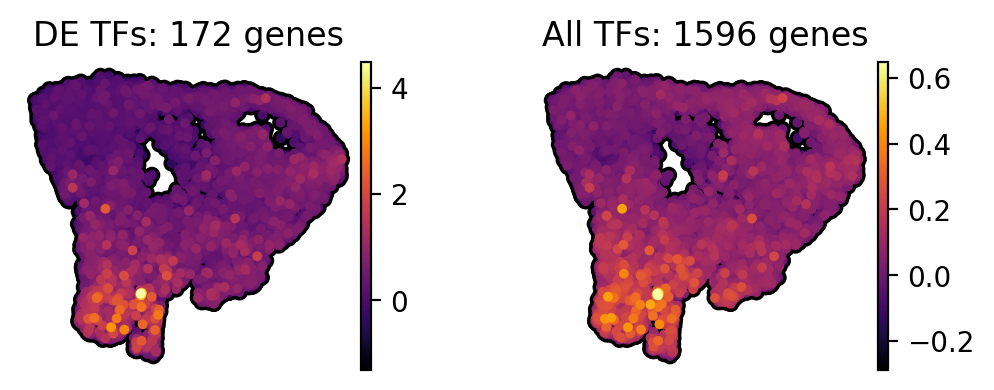

Scoring Fibroblasts genes...

	 N DE genes: 187
	 N total genes: 423
computing score 'DE_Fibroblasts_score'
    finished (0:00:02)
computing score 'All_Fibroblasts_score'
    finished (0:00:03)


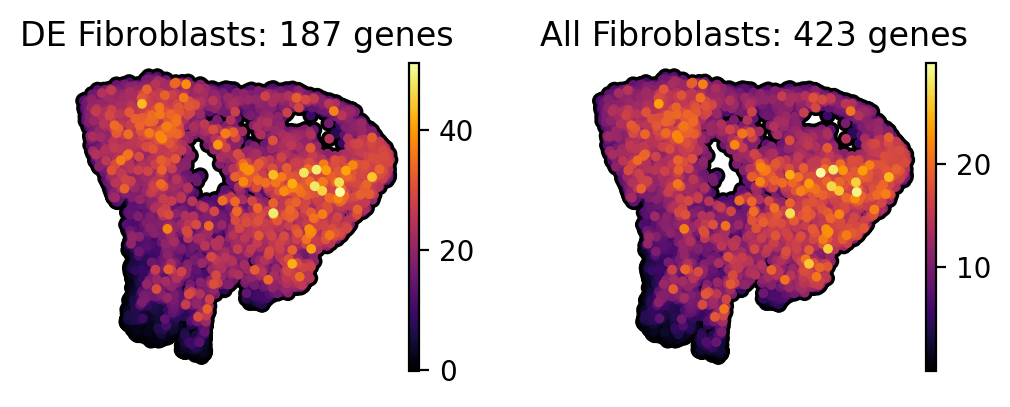

Scoring Myofibroblasts genes...

	 N DE genes: 122
	 N total genes: 227
computing score 'DE_Myofibroblasts_score'
    finished (0:00:02)
computing score 'All_Myofibroblasts_score'
    finished (0:00:03)


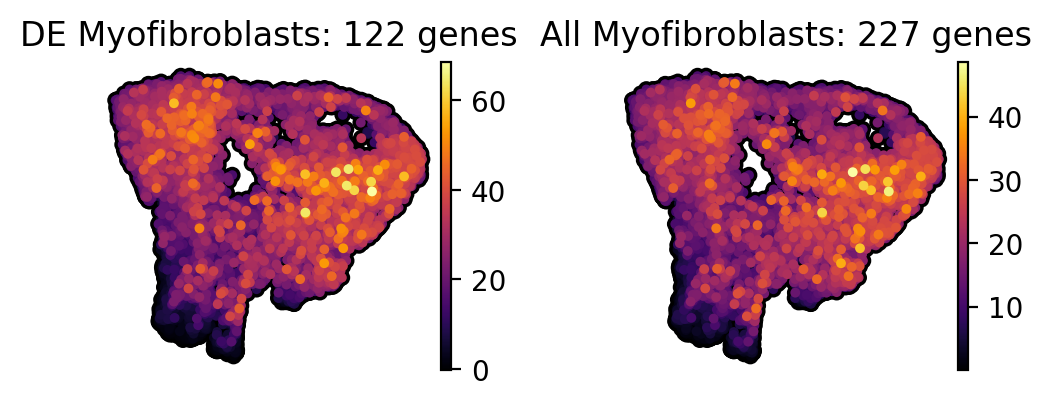

Scoring Myogenic genes...

	 N DE genes: 129
	 N total genes: 389
computing score 'DE_Myogenic_score'
    finished (0:00:02)
computing score 'All_Myogenic_score'
    finished (0:00:03)


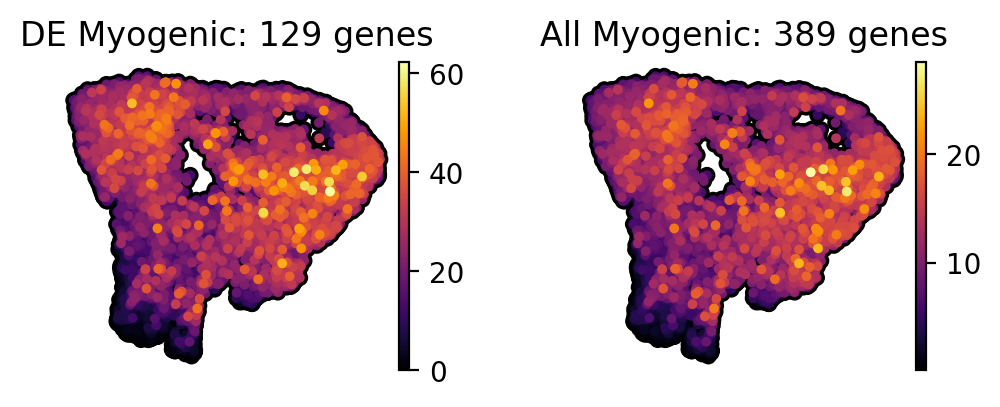

Scoring cell_cycle genes...

	 N DE genes: 141
	 N total genes: 760
computing score 'DE_cell_cycle_score'
    finished (0:00:02)
computing score 'All_cell_cycle_score'
    finished (0:00:03)


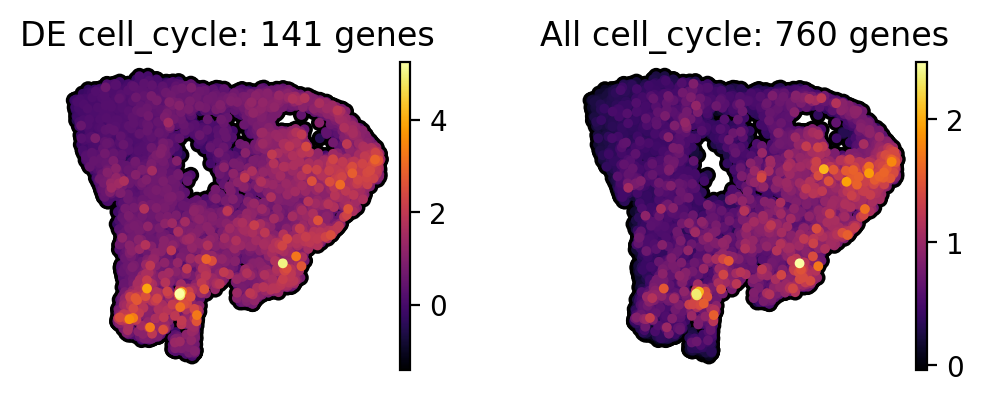

Scoring AS genes...

	 N DE genes: 72
	 N total genes: 262
computing score 'DE_AS_score'
    finished (0:00:02)
computing score 'All_AS_score'
    finished (0:00:03)


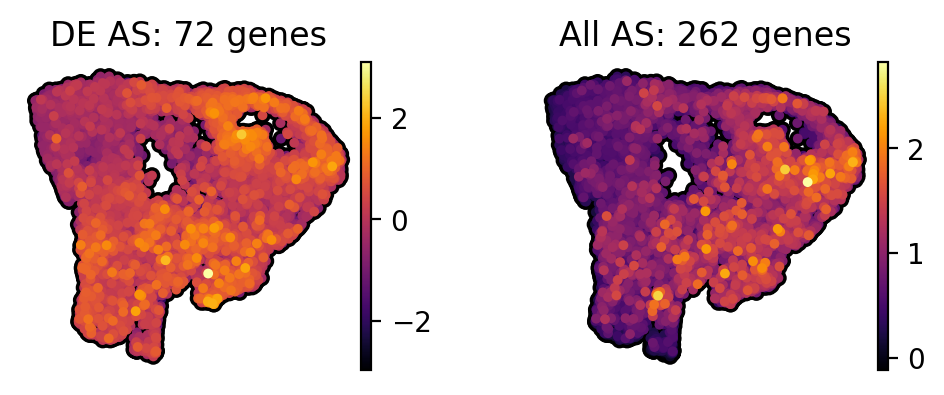

Scoring Circadian genes...

	 N DE genes: 8
	 N total genes: 54
computing score 'DE_Circadian_score'
    finished (0:00:02)
computing score 'All_Circadian_score'
    finished (0:00:02)


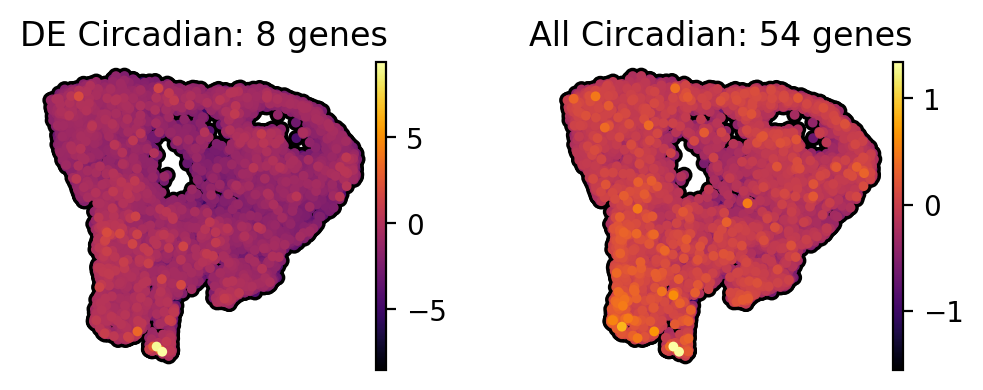

Scoring Core_reprogramming genes...

	 N DE genes: 23
	 N total genes: 139
computing score 'DE_Core_reprogramming_score'
    finished (0:00:02)
computing score 'All_Core_reprogramming_score'
    finished (0:00:03)


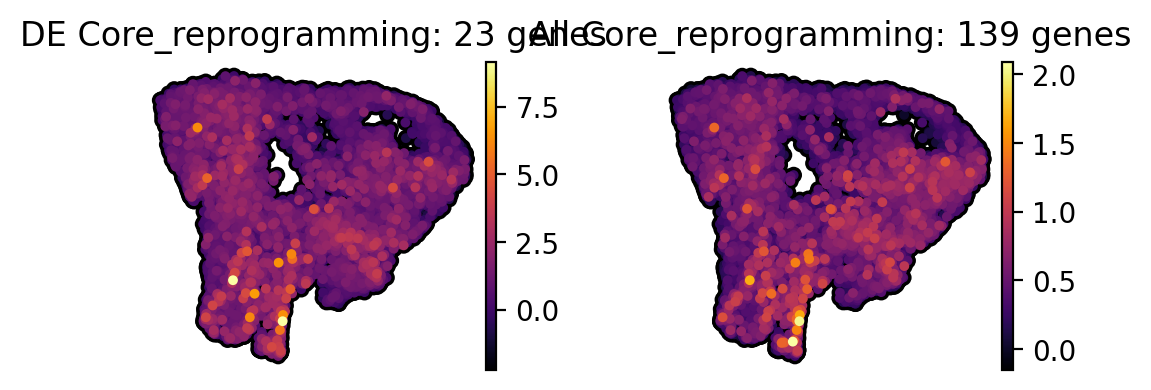

Scoring Senescence genes...

	 N DE genes: 7
	 N total genes: 36
computing score 'DE_Senescence_score'
    finished (0:00:02)
computing score 'All_Senescence_score'
    finished (0:00:02)


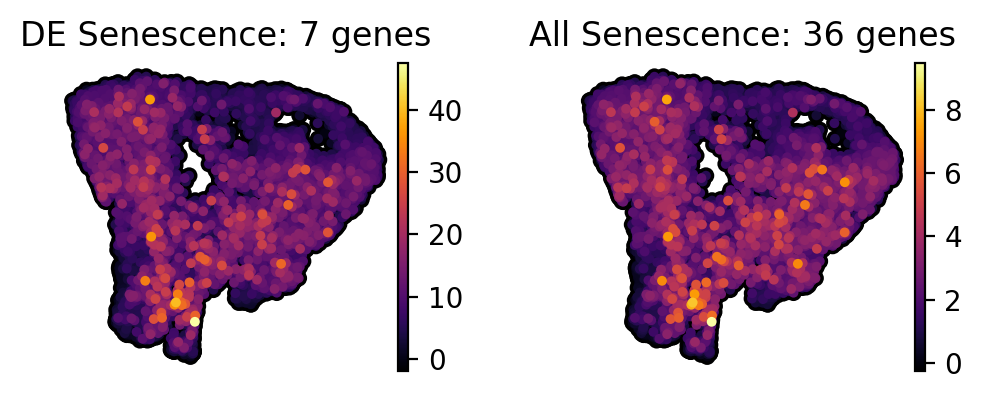

Scoring DNA_damage genes...

	 N DE genes: 93
	 N total genes: 498
computing score 'DE_DNA_damage_score'
    finished (0:00:02)
computing score 'All_DNA_damage_score'
    finished (0:00:03)


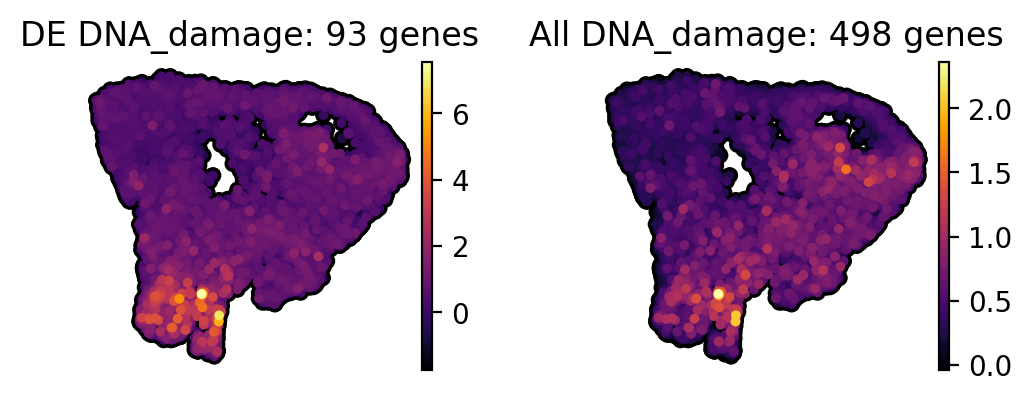

In [64]:
# for term in categories.keys():
#     print(f"Scoring {term} genes...\n")
    
#     gene_set = df[df['categories'].str.contains(term, na=False)]
#     print(f"\t N DE genes: {gene_set['names'].nunique()}")
#     # print(gene_set['group'].value_counts())
    
#     gene_list = gene_set['names'].unique()

#     all_gene_list = adata.uns[term]
#     all_gene_list = [gene for gene in all_gene_list if gene in adata.var_names]
#     print(f"\t N total genes: {len(all_gene_list)}")

#     de_score_name = f"DE_{term}_score"
#     all_score_name = f"All_{term}_score"

#     ctrl_size = 1000

#     sc.tl.score_genes(
#         adata,
#         gene_list=gene_list,
#         score_name=de_score_name,
#         ctrl_size=ctrl_size,
#         use_raw=False,
#     )

#     sc.tl.score_genes(
#         adata,
#         gene_list=all_gene_list,
#         score_name=all_score_name,
#         ctrl_size=ctrl_size,
#         use_raw=False,
#     )

#     plt.rcParams['figure.figsize'] = 2, 2

#     sc.pl.umap(
#         adata,
#         color=[de_score_name, all_score_name],
#         size=50,
#         ncols=2,
#         add_outline=True,
#         outline_color=('k', 'k'),
#         color_map='inferno',
#         frameon=False,
#         alpha=1,
#         title=[f"DE {term}: {len(gene_list)} genes", f"All {term}: {len(all_gene_list)} genes"],
#         show=True
#     )

Scoring DE Senescence genes...

7
group
mmMYOD1            7
siPRRX1            4
siPRRX1/mmMYOD1    4
Name: count, dtype: int64
36
computing score 'DE_Senescence_score'
    finished (0:00:02)
computing score 'All_Senescence_score'
    finished (0:00:03)


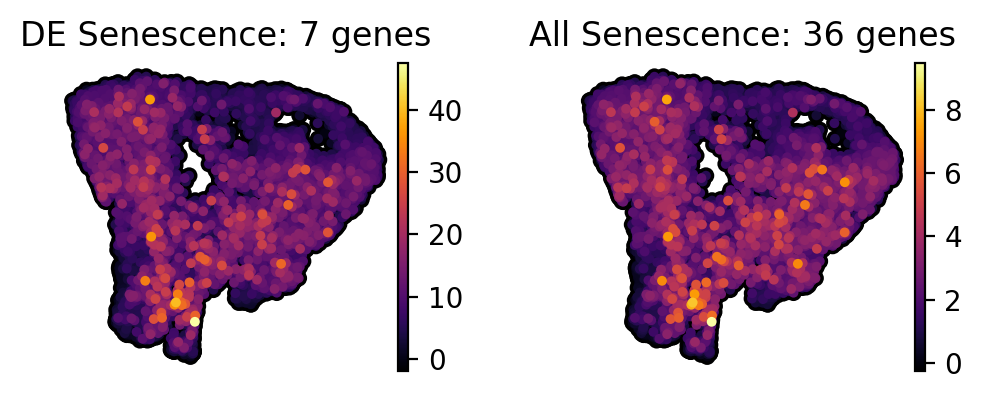

In [60]:
# term = 'Senescence'

# print(f"Scoring DE {term} genes...\n") 
# gene_set = df[df['categories'].str.contains(term, na=False)]
# print(gene_set['names'].nunique())
# print(gene_set['group'].value_counts())
# gene_set.head()


# gene_list = gene_set['names'].unique()


# all_gene_list = adata.uns[term]
# all_gene_list = [gene for gene in all_gene_list if gene in adata.var_names]
# print(len(all_gene_list))

# # score DE genes (and all genes) belonging to a specific term
# de_score_name = f"DE_{term}_score"
# all_score_name = f"All_{term}_score"

# ctrl_size = 1000

# # DE
# sc.tl.score_genes(
#     adata,
#     gene_list=gene_list,
#     score_name=de_score_name,
#     ctrl_size=ctrl_size,
#     # ctrl_size=len(gene_list),
#     use_raw=False,
# )

# # All
# sc.tl.score_genes(
#     adata,
#     gene_list=all_gene_list,
#     score_name=all_score_name,
#     ctrl_size=ctrl_size,
#     # ctrl_size=len(all_gene_list),
#     use_raw=False,
# )

# plt.rcParams['figure.figsize'] = 2, 2

# sc.pl.umap(
#     adata,
#     color=[de_score_name, all_score_name],
#     size=50,
#     ncols=2,
#     add_outline=True,
#     outline_color=('k', 'k'),
#     color_map='inferno',
#     frameon=False,
#     alpha=1,
#     title=[f"DE {term}: {len(gene_list)} genes", f"All {term}: {len(all_gene_list)} genes"],
# )  

In [79]:
adata

AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase', 'UMAP_1', 'UMAP_2', 'DE_DNA_damage_score', 'All_DNA_damage_score', 'DE_Senescence_score', 'All_Senescence_score', 'DE_TFs_score', 'All_TFs_score', 'DE_Fibroblasts_score', 'All_Fibroblasts_score', 'DE_Myofibroblasts_score', 'All_Myofibroblasts_score', 'DE_Myogenic_score', 'All_Myogeni

20


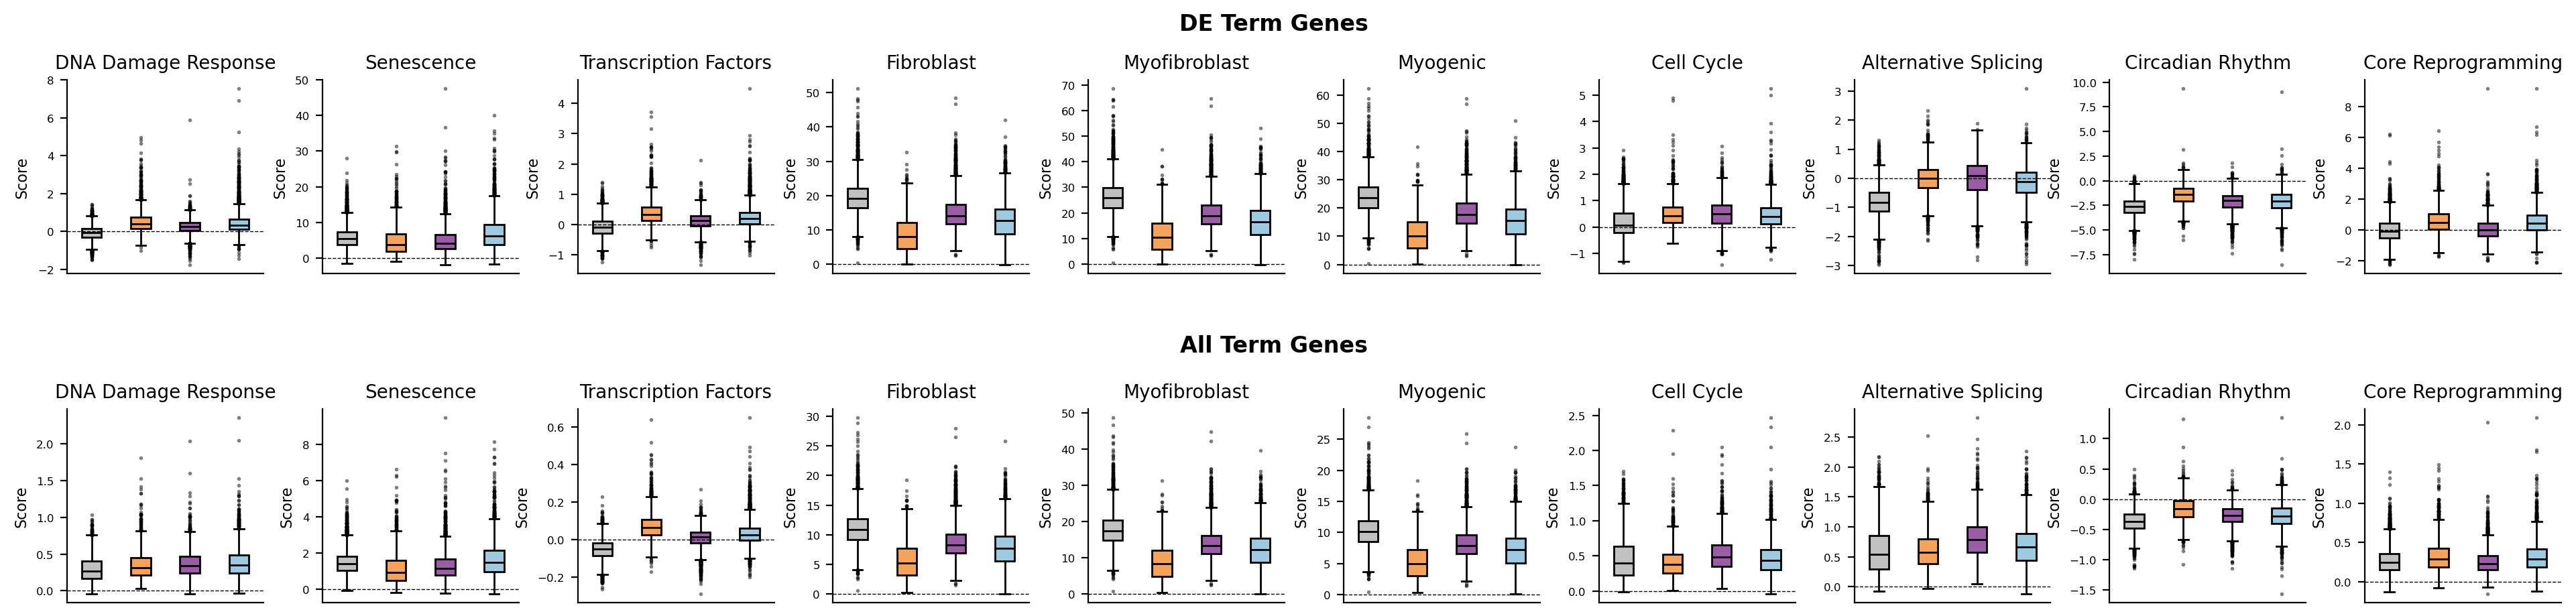

In [81]:
# scores_to_plot = [col for col in adata.obs if col.startswith('DE')] + [col for col in adata.obs if col.startswith('All')]
# print(len(scores_to_plot))

# title_map = {
#     "AS": "Alternative Splicing",
#     "TFs": "Transcription Factors",
#     "Fibroblasts": "Fibroblast",
#     "Myofibroblasts": "Myofibroblast",
#     "Myogenic": "Myogenic",
#     "Core_reprogramming": "Core Reprogramming",
#     "Circadian": "Circadian Rhythm",
#     "cell_cycle": "Cell Cycle",
#     "DNA_damage": "DNA Damage Response",
#     "Senescence": "Senescence",
# }

# fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(20, 5), dpi=200)
# axes = axes.flatten()

# for i, score in enumerate(scores_to_plot):
#     ax = axes[i]
    
#     title = score # Default title if no specific mapping
#     for k, v in title_map.items():
#         if k in score:
#             title = f"{v}"
#             # # Determine if it's "DE" or "All" and prepend
#             # if "DE_" in score:
#             #     title = f"DE {v}"
#             # elif "All_" in score:
#             #     title = f"All {v}"
#             # break
#     # title = next((v for k, v in title_map.items() if k in score), score)
    
#     sns.boxplot(
#         data=adata.obs,
#         x='pooled_condition',
#         y=score,
#         width=0.4,
#         linecolor='k',
#         hue='pooled_condition',
#         palette=color_map,
#         legend=False,
#         saturation=1,
#         flierprops={'markersize': 1, 'alpha': 0.5},
#         ax=ax,
#         zorder=0,
#     )
    
#     ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=1)
    
#     ax.set_title(title, fontsize=10)
#     ax.set_xlabel("")
#     ax.set_xticks([])
#     ax.set_ylabel("Score", fontsize=8)
#     ax.tick_params(axis='y', labelsize=6)
#     sns.despine(ax=ax)

    
# fig.text(0.5, 0.96, "DE Term Genes", ha='center', va='top', fontsize=12, weight='bold')
# fig.text(0.5, 0.48, "All Term Genes", ha='center', va='top', fontsize=12, weight='bold')
    
# plt.subplots_adjust(
#     top=0.86,  # space for top title
#     bottom=0.08,
#     left=0.05,
#     right=0.98,
#     hspace=0.7,  # vertical spacing between rows
#     wspace=0.3   # horizontal spacing between columns
# )

# plt.show()

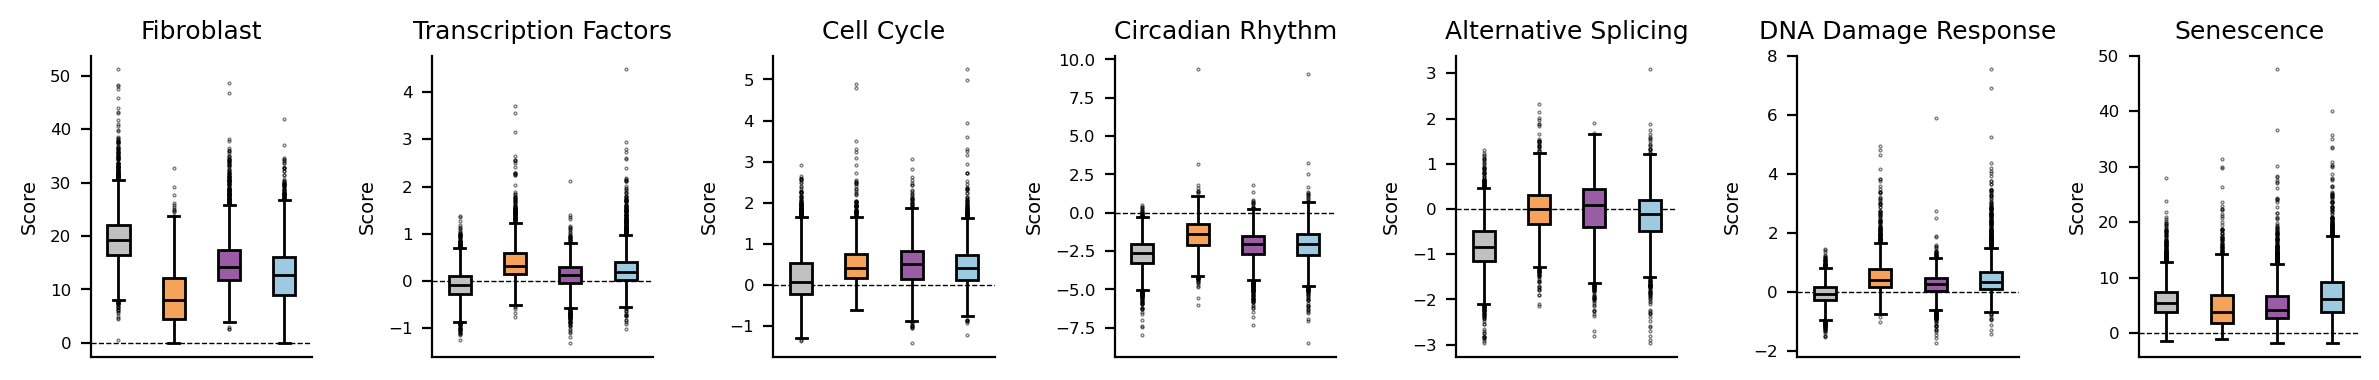

In [90]:
# scores_to_plot = [
#     "DE_Fibroblasts_score",
#     "DE_TFs_score",
#     "DE_cell_cycle_score",
#     "DE_Circadian_score",
#     "DE_AS_score",
#     "DE_DNA_damage_score",
#     "DE_Senescence_score",
# ]

# fig, axes = plt.subplots(nrows=1, ncols=len(scores_to_plot), figsize=(12, 2), dpi=200)
# axes = axes.flatten()

# for i, score in enumerate(scores_to_plot):
#     ax = axes[i]
    
#     title = score # Default title if no specific mapping
#     for k, v in title_map.items():
#         if k in score:
#             title = f"{v}"
    
#     sns.boxplot(
#         data=adata.obs,
#         x='pooled_condition',
#         y=score,
#         width=0.4,
#         linecolor='k',
#         linewidth=1,
#         hue='pooled_condition',
#         palette=color_map,
#         legend=False,
#         saturation=1,
#         flierprops={'markersize': 0.5, 'alpha': 0.5},
#         ax=ax,
#         zorder=1,
#     )
    
#     ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)
    
#     ax.set_title(title, fontsize=9)
#     ax.set_xlabel("")
#     ax.set_xticks([])
#     ax.set_ylabel("Score", fontsize=7)
#     ax.tick_params(axis='y', labelsize=6)
#     sns.despine(ax=ax)

# plt.tight_layout()
# plt.show()    

In [61]:
wiki.head()

,TGF Beta Receptor Signaling WP560,TGF Beta Signaling Pathway WP366,Hippo Signaling Regulation WP4540,Hippo YAP Signaling WP4537,Mechanoreg And Pathology Of YAP TAZ Hippo And Non Hippo Mechs WP4534,Overview Of Proinflammatory And Profibrotic Mediators WP5095
0,TGFB1,TGFB1,PDGFRB,MAP4K2,MAP4K2,TGFB1
1,EGF,UBE2I,PDGFRA,WWTR1,WWTR1,OSM
2,JUN,TRAP1,PRKAB1,MAP4K3,MAP4K3,IL1F10
3,FOXH1,NUP214,PRKAB2,YAP1,MAP4K1,CXCL10
4,LIF,FOXH1,TEK,MAP4K1,MST1,CXCL11


N terms: 1
N genes: 83
Using 5 DE genes...
computing score 'fibrotic_score'
    finished (0:00:02)


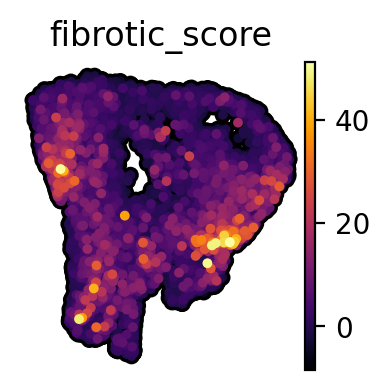

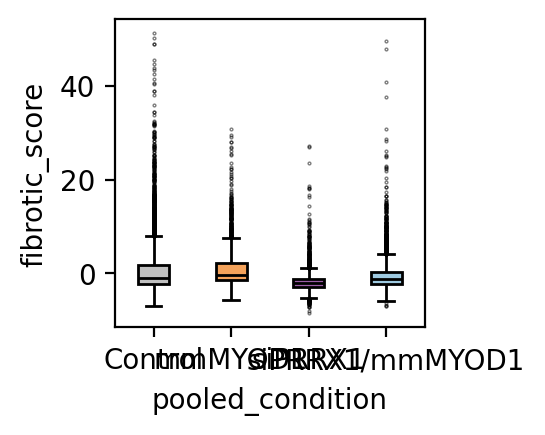

In [69]:
term = 'fibrotic'

terms = [col for col in wiki if term.lower() in col.lower()]
print(f"N terms: {len(terms)}")
tdf = wiki[terms]
term_genes = list(set(tdf.stack().tolist()))
term_genes = [gene for gene in term_genes if gene in adata.var_names]
print(f"N genes: {len(term_genes)}")

only_de = True

if only_de:
    term_genes = [gene for gene in term_genes if gene in pdf['names'].unique()]
    print(f'Using {len(term_genes)} DE genes...')

sc.tl.score_genes(
    adata,
    gene_list=term_genes,
    score_name=f'{term}_score',
    ctrl_size=1000,
    use_raw=False,
)

plt.rcParams['figure.figsize'] = 2, 2

sc.pl.umap(
    adata,
    color=f'{term}_score',
    size=50,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    color_map='inferno',
    frameon=False,
    alpha=1,
    title=f'{term}_score',
    show=True
)

sns.boxplot(
    data=adata.obs,
    x='pooled_condition',
    y=f'{term}_score',
    width=0.4,
    linecolor='k',
    linewidth=1,
    hue='pooled_condition',
    palette=color_map,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
)

plt.show()

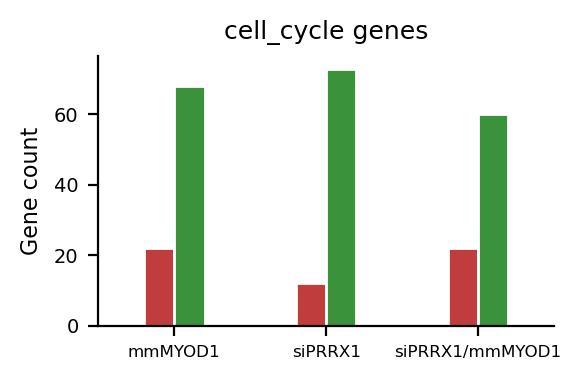

In [110]:
# Get counts for N up and down regulated genes per condition
module = 'cell_cycle'

d0 = df[df['categories'].str.contains(module, na=False)]

d0 = (
    d0.groupby(['group', 'regulation'], observed=True)
    .size()
    .reset_index(name='count')
)

plt.rcParams['figure.figsize'] = 3, 2

sns.barplot(
    data=d0,
    x='group',
    y='count',
    hue='regulation',
    palette={'Upregulated': 'tab:green', 'Downregulated': 'tab:red'},
    dodge=True,
    width=0.4,
    ec='white',
    legend=False,
)


plt.title(f'{module} genes', fontsize=9)
plt.ylabel('Gene count', fontsize=8)
plt.xlabel('')
plt.yticks(fontsize=7)
plt.xticks(fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

In [87]:
df[df['names'] == 'MYOD1']

,group,names,categories,regulation
0,mmMYOD1,MYOD1,"Myogenic, TFs",Upregulated
729,siPRRX1/mmMYOD1,MYOD1,"Myogenic, TFs",Upregulated


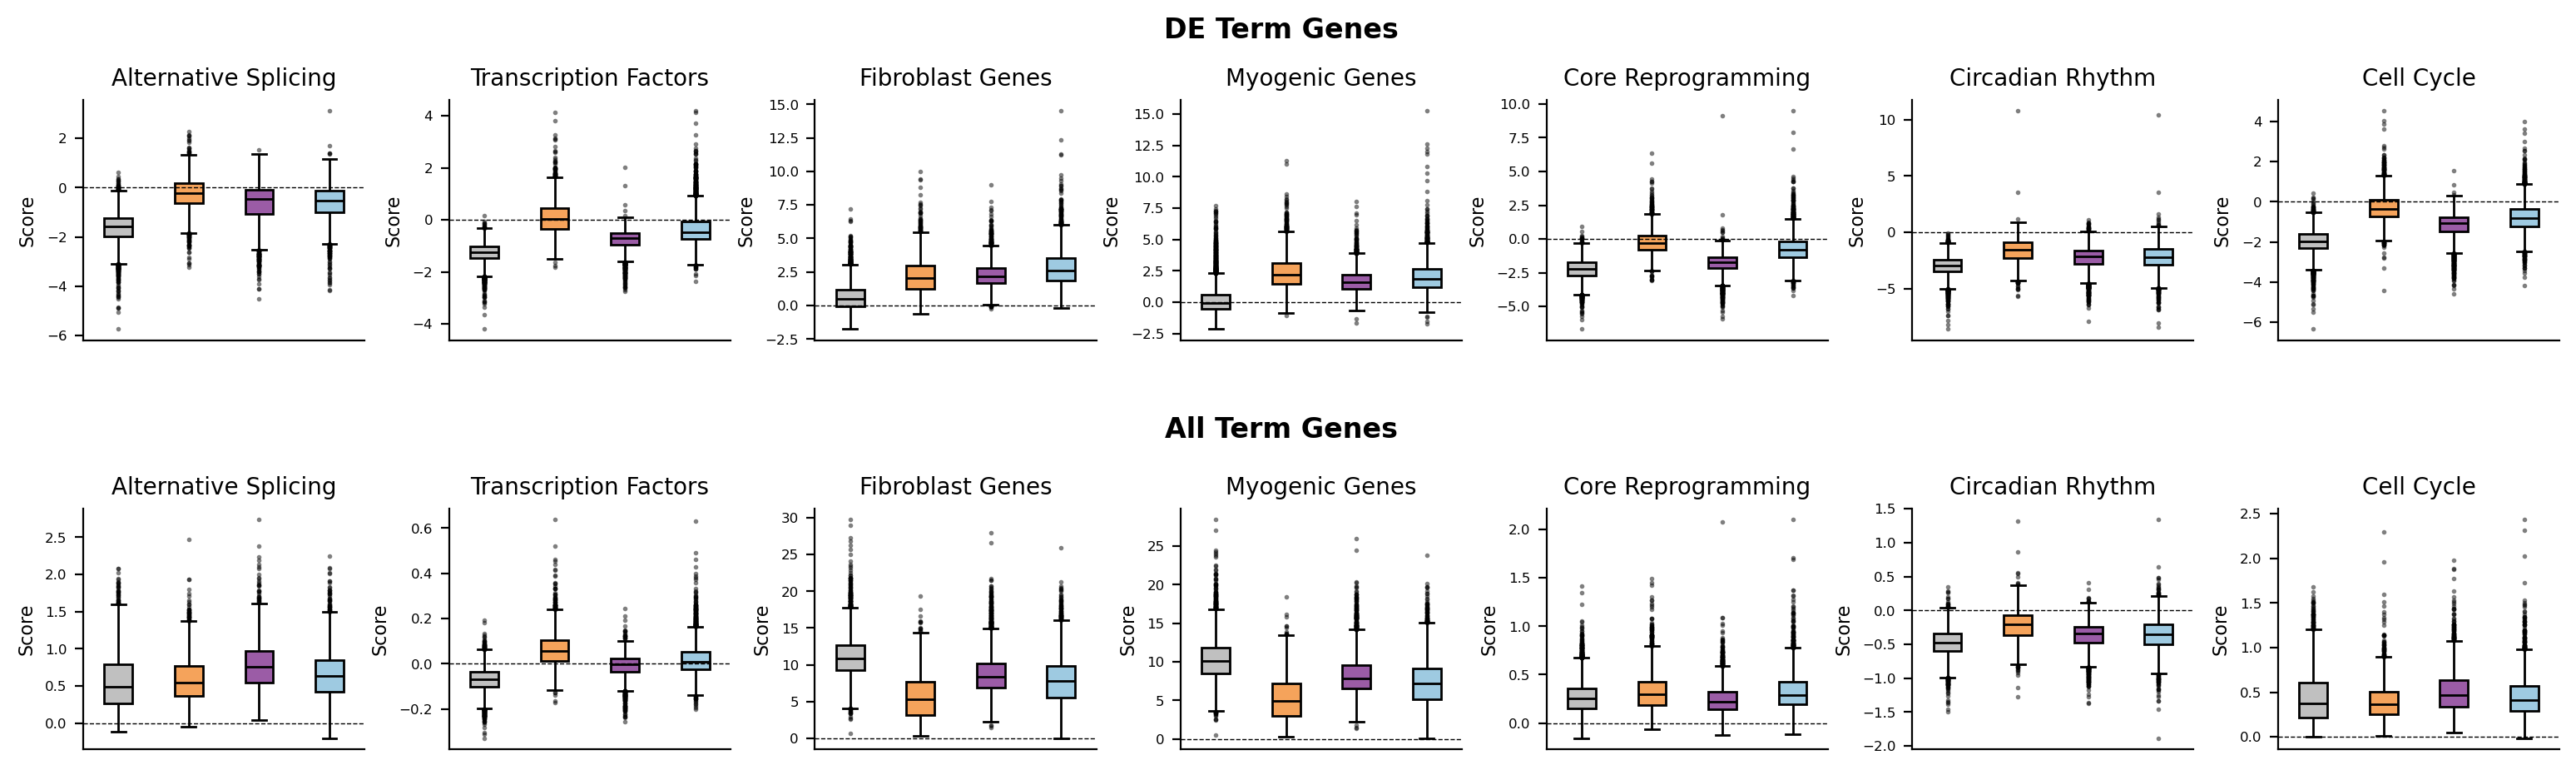

In [118]:
# scores_to_plot = [
#     "DE_AS_score", "DE_TFs_score", "DE_Fibroblasts_score", "DE_Myogenic_score", 
#     "DE_Core_reprogramming_score", "DE_Circadian_score", "DE_cell_cycle_score", "
#     "All_AS_score", "All_TFs_score", "All_Fibroblasts_score", "All_Myogenic_score", 
#     "All_Core_reprogramming_score", "All_Circadian_score", "All_cell_cycle_score",
# ]

# title_map = {
#     "AS": "Alternative Splicing",
#     "TFs": "Transcription Factors",
#     "Fibroblasts": "Fibroblast Genes",
#     "Myogenic": "Myogenic Genes",
#     "Core_reprogramming": "Core Reprogramming",
#     "Circadian": "Circadian Rhythm",
#     "cell_cycle": "Cell Cycle"
# }

# fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(16, 5), dpi=200)
# axes = axes.flatten()

# for i, score in enumerate(scores_to_plot):
#     ax = axes[i]
    
#     title = next((v for k, v in title_map.items() if k in score), score)
    
#     sns.boxplot(
#         data=adata.obs,
#         x='pooled_condition',
#         y=score,
#         width=0.4,
#         linecolor='k',
#         hue='pooled_condition',
#         palette=color_map,
#         legend=False,
#         saturation=1,
#         flierprops={'markersize': 1, 'alpha': 0.5},
#         ax=ax,
#         zorder=0,
#     )
    
#     ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=1)
    
#     ax.set_title(title, fontsize=10)
#     ax.set_xlabel("")
#     ax.set_xticks([])
#     ax.set_ylabel("Score", fontsize=8)
#     ax.tick_params(axis='y', labelsize=6)
#     sns.despine(ax=ax)

    
# fig.text(0.5, 0.96, "DE Term Genes", ha='center', va='top', fontsize=12, weight='bold')
# fig.text(0.5, 0.48, "All Term Genes", ha='center', va='top', fontsize=12, weight='bold')
    
# plt.subplots_adjust(
#     top=0.86,  # space for top title
#     bottom=0.08,
#     left=0.05,
#     right=0.98,
#     hspace=0.7,  # vertical spacing between rows
#     wspace=0.3   # horizontal spacing between columns
# )

# plt.show()

In [122]:
# terms_to_plot = [
#     "AS", "TFs", "Fibroblasts", "Myogenic", 
#     "Core_reprogramming", "Circadian", "cell_cycle"
# ]

# max_cells_per_condition = 2000

# # Sample cells: stratified by pooled_condition
# np.random.seed(42)
# sampled_idx = (
#     adata.obs
#     .groupby("pooled_condition", observed=True)
#     .apply(lambda x: x.sample(min(len(x), max_cells_per_condition)))
#     .index.get_level_values(1)
# )

# adata_sampled = adata[sampled_idx].copy()

# # For each term, compute average expression for DE and All gene sets
# for term in terms_to_plot:
#     print(f"Scoring sampled log-normalized expression for: {term}")

#     # DE gene set
#     de_genes = df[df['Categories'].str.contains(term, na=False)]['names'].unique()
#     de_genes = [g for g in de_genes if g in adata.var_names]

#     # All gene set
#     all_genes = [g for g in adata.uns[term] if g in adata.var_names]

#     # Mean expression across sampled cells
#     adata_sampled.obs[f"DE_{term}_avg_expr"] = np.array(adata_sampled[:, de_genes].X.mean(axis=1)).flatten()
#     adata_sampled.obs[f"All_{term}_avg_expr"] = np.array(adata_sampled[:, all_genes].X.mean(axis=1)).flatten()


# # for term in terms_to_plot:
# #     print(f"Getting log-normalized expression for: {term}")

# #     # DE genes from df
# #     de_genes = df[df['Categories'].str.contains(term, na=False)]['names'].unique()
# #     de_genes = [g for g in de_genes if g in adata.var_names]

# #     # All genes from adata.uns
# #     all_genes = [g for g in adata.uns[term] if g in adata.var_names]

# #     # Calculate per-cell mean expression (log-normalized)
# #     adata.obs[f"DE_{term}_avg_expr"] = np.array(adata[:, de_genes].X.mean(axis=1)).flatten()
# #     adata.obs[f"All_{term}_avg_expr"] = np.array(adata[:, all_genes].X.mean(axis=1)).flatten()

/tmp/ipykernel_2623838/3727490193.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pooled_condition")
/tmp/ipykernel_2623838/3727490193.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), max_cells_per_condition)))


Scoring sampled log-normalized expression for: AS
Scoring sampled log-normalized expression for: TFs
Scoring sampled log-normalized expression for: Fibroblasts
Scoring sampled log-normalized expression for: Myogenic
Scoring sampled log-normalized expression for: Core_reprogramming
Scoring sampled log-normalized expression for: Circadian
Scoring sampled log-normalized expression for: cell_cycle


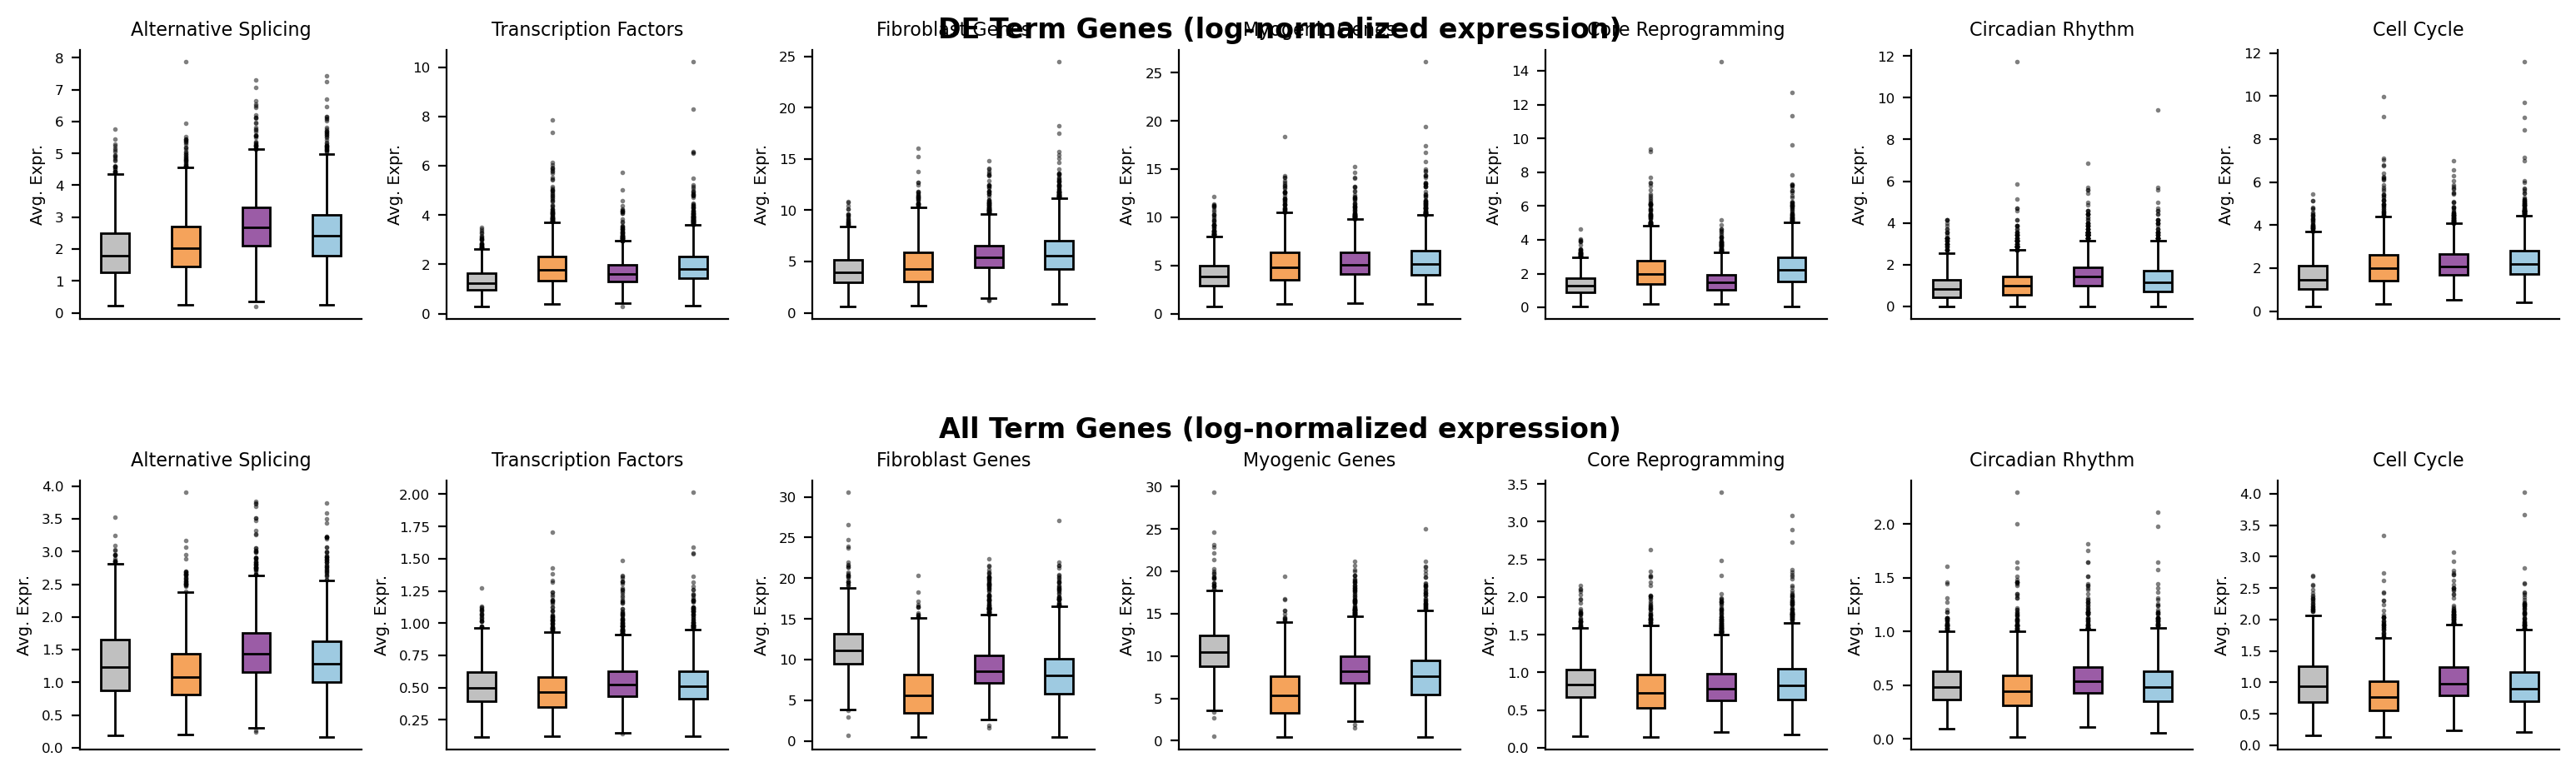

In [123]:
# fig, axes = plt.subplots(2, 7, figsize=(16, 5), dpi=200)
# axes = axes.flatten()

# for i, term in enumerate(terms_to_plot):
#     for j, prefix in enumerate(["DE", "All"]):
#         score_key = f"{prefix}_{term}_avg_expr"
#         ax_index = i + j * 7  # Top row: DE (j=0), Bottom row: All (j=1)
#         ax = axes[ax_index]

#         # Get human-readable title
#         title = title_map.get(term, term)

#         sns.boxplot(
#             data=adata_sampled.obs,
#             x='pooled_condition',
#             y=score_key,
#             width=0.4,
#             linecolor='k',
#             hue='pooled_condition',
#             palette=color_map,
#             legend=False,
#             saturation=1,
#             flierprops={'markersize': 1, 'alpha': 0.5},
#             ax=ax
#         )

#         # ax.axhline(0, linestyle='--', linewidth=0.5, color='k')

#         ax.set_title(title, fontsize=8)
#         ax.set_xlabel("")
#         ax.set_xticks([])
#         ax.set_ylabel("Avg. Expr.", fontsize=7)
#         ax.tick_params(axis='y', labelsize=6)
#         sns.despine(ax=ax)

# # Add row-level titles
# fig.text(0.5, 0.96, "DE Term Genes (log-normalized expression)", ha='center', va='top', fontsize=12, weight='bold')
# fig.text(0.5, 0.48, "All Term Genes (log-normalized expression)", ha='center', va='top', fontsize=12, weight='bold')

# # Adjust layout
# plt.subplots_adjust(
#     top=0.92,
#     bottom=0.08,
#     left=0.05,
#     right=0.98,
#     hspace=0.6,
#     wspace=0.3
# )

# plt.show()

In [121]:
adata.obs['pooled_condition'].value_counts()

pooled_condition
Control            6960
siPRRX1/mmMYOD1    3462
siPRRX1            3437
mmMYOD1            2256
Name: count, dtype: int64

In [74]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# GSEA

In [39]:
adata

AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase', 'UMAP_1', 'UMAP_2'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_

In [ ]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_all',
)

print(deg.shape)
deg.head()

# filter for significant DEGs
pval_cutoff = 0.01       # p-value threshold
logfc_cutoff = 0.5       # log fold change threshold
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

sig = deg.copy()

sig['abs_lfc'] = sig['logfoldchanges'].apply('abs')

sig = sig[(sig['abs_lfc'] > logfc_cutoff) & (sig['pvals_adj'] < pval_cutoff)]
print(f"N unique significant DEGs: {sig['names'].nunique()}")
sig.head()

# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

print(sig.shape)
print(gdf.shape)

# filter sig DEGs for named protein-coding genes
pdf = pd.merge(sig, gdf, how='left', on='names')

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith('ENSG')] # remove unnamed genes

print(pdf.shape)
print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}")

pdf = pdf.sort_values(by='logfoldchanges', ascending=False)
# pdf.groupby('group', observed=True)[['group', 'names', 'logfoldchanges']].head()

In [ ]:
# Define the list of conditions to loop through
conditions_to_plot = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

plt.rcParams['figure.dpi'] = 300

n_genes = 500 
database="GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database = "CellMarker_2024"
# database = "TF_Perturbations_Followed_by_Expression"
# database = "WikiPathways_2024_Human"
# database='GO_Molecular_Function_2025'
# database='MSigDB_Hallmark_2020' # interesting
# database='Tabula_Sapiens'
n_terms = 10
alpha = 0.01

# Loop through each condition to generate a separate plot
for condition in conditions_to_plot:
    print(f"Running Enrichment on {condition} group with {n_genes} genes using database: {database}...")

    # Filter pdf for the current condition and get gene list
    tmp = pdf[pdf['group'] == condition]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    gene_list = tmp['names'].head(n_genes).to_list()


    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=database,
        organism='human', # Or 'mouse' if appropriate for your data
        outdir=None, # Prevents writing results to disk, if not desired
    )
    edf = enr.results.copy()


    # Filter for significant terms
    # Ensure there are significant terms before proceeding to plotting
    if not edf.empty:
        edf = edf[edf['Adjusted P-value'] < alpha].copy()
        print(f"Significant terms for {condition}: {edf['Term'].nunique()}\n(alpha = {alpha})")

        if edf.empty:
            print(f"No significant terms found for condition: {condition}. Skipping plot.")
            continue # Skip to the next condition if no significant terms

        # Create plotting columns
        overlap_split = edf["Overlap"].str.split("/", expand=True).astype(int)
        edf['Overlap_pct'] = (100 * overlap_split[0] / overlap_split[1]).round(1)
        edf['log10_adj_pval'] = np.log10(1 / edf['Adjusted P-value'])
        # Remove (GO:...) and (Reactome:...) identifiers from term names
        edf['Term'] = edf['Term'].str.replace(r'\s\(GO:\d+\)', '', regex=True)
        edf['Term'] = edf['Term'].str.replace(r'\s\(Reactome:R-HSA-\d+\)', '', regex=True)

        # Calculate combined score with adjusted p-val
        edf['adj_score'] = -np.log(edf['Adjusted P-value']) * edf['Odds Ratio']

        # Get top n terms sorted by significance (Adjusted P-value)
        edf = edf.sort_values(by='Adjusted P-value', ascending=True).head(n_terms).copy()

        # Sort by adjusted combined score for plotting (descending)
        edf = edf.sort_values(by='adj_score', ascending=False).copy()

        # --- Plotting Code for current condition ---
        # Create a new figure and axes for each plot in the loop
        fig, ax = plt.subplots(figsize=(2, 4))

        sns.scatterplot(
            data=edf,
            x='adj_score',
            y='Term',
            ec='k', # Edge color
            linewidth=0.3,
            hue='log10_adj_pval', # Color by log10(1/Adjusted P-value)
            palette='viridis', # Color map
            size='Overlap_pct', # Size of points by overlap percentage
            zorder=3, # Ensures scatter points are on top of grid
            ax=ax # Explicitly pass the axes object to seaborn
        )

        # Set plot margins
        x_margin = 0.25
        y_margin = 0.1
        ax.margins(x=x_margin, y=y_margin)

        # Add grid
        ax.grid(
            True,
            c='#DEDEDE', # Grid color
            zorder=0, # Ensures grid is behind scatter points
        )

        # Remove y-axis label as tick labels are descriptive
        ax.set_ylabel("")

        # --- Y-tick label wrapping ---
        original_ylabels = edf['Term'].to_list()
        wrap_width = 60 # Adjust this width as needed for your plot size and text length
        wrapped_ylabels = [textwrap.fill(label, wrap_width) for label in original_ylabels]
        ax.set_yticklabels(wrapped_ylabels, fontsize=9)
        # --- End of Y-tick label wrapping ---

        # Colorbar for log10_adj_pval
        norm = plt.Normalize(edf['log10_adj_pval'].min(), edf['log10_adj_pval'].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])
        # `fig.colorbar` is used with `ax` to attach it to the current axes' figure
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.09, shrink=0.3)
        cbar.set_label('log$_{10} \\frac{1}{q}$', fontsize='9')
        cbar.ax.tick_params(labelsize=8)

        # Overlap percentage legend
        min_overlap = edf['Overlap_pct'].min()
        max_overlap = edf['Overlap_pct'].max()

        # Scaling for legend handles to match scatterplot point sizes
        scaled_min_size = min_overlap * 3 # Adjust multiplier (3) to match visual size
        scaled_max_size = max_overlap * 3 # Adjust multiplier (3) to match visual size

        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{min_overlap:.1f}%',
                       markersize=np.sqrt(scaled_min_size / np.pi), linestyle=''),
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{max_overlap:.1f}%',
                       markersize=np.sqrt(scaled_max_size / np.pi), linestyle='')
        ]

        # Gene Overlap legend setup
        legend = ax.legend(handles=legend_handles, title='Gene\nOverlap',
                            loc='upper right', # Location of the legend
                            bbox_to_anchor=(1.7, 0.98), # Position relative to the axes (adjusted for space)
                            fontsize=8, title_fontsize=9, frameon=False, labelspacing=0.75)


        legend_title = legend.get_title()
        legend_title.set_ha('center')

        # Set x-axis label and ticks
        ax.set_xlabel("Adjusted Score", fontsize=9)
        # Ensure x-ticks are consistently formatted
        # ax.set_xticks(ax.get_xticks())
        # ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=8)

        ax.set_title(f"{condition}")

        # Adjust layout to prevent elements from overlapping
        # Rect parameter [left, bottom, right, top] in figure coordinates
        # Adjust 'right' (1.4 here) if legend is still cut off or too far
        plt.tight_layout(rect=[0, 0, 1.4, 1])
        plt.show()



In [ ]:
genes_to_plot = [x for x in cell_cycle_genes if x in adata.var_names]
print(f"{len(genes_to_plot)} kept")

plt.rcdefaults()

sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    # standard_scale='var',
)

In [ ]:
sig_fb = sig[sig['names'].isin(fb_genes)]
# sig_fb = sig_fb.sort_values(by='abs_lfc', ascending=False)

# get top DE fibroblast genes
sig_fb_genes = sig_fb.sort_values(by='abs_lfc', ascending=False)['names'].unique()

n_genes = 20

top_sig_fb_genes = sig_fb_genes[:n_genes]

# Sort genes by logfoldchanges for plotting
fb_top = sig_fb[sig_fb['names'].isin(top_sig_fb_genes)]
print(fb_top.shape)

fb_top = fb_top.sort_values(by='logfoldchanges')
fb_top_plotting = fb_top['names'].unique()


sc.pl.MatrixPlot(
    adata,
    var_names=fb_top_plotting,
    groupby='pooled_condition',
    layer='log_norm',
    standard_scale='var',
).show()
# ).swap_axes(swap_axes=True).show()

In [ ]:
sc.pl.DotPlot(
    adata,
    var_names=fb_top_plotting,
    groupby='pooled_condition',
    layer='log_norm',
    standard_scale='var',
).show()

In [ ]:
pdf = sig.copy()

pdf = pdf[pdf['names'].isin(tf_list)]

n_genes = 6

top_tfs = (
    pdf.sort_values(['group', 'logfoldchanges'], ascending=[True, False])
    .groupby('group')['names']
    .head(n_genes).unique()
    .tolist()
)

print(len(top_tfs))


pdf = deg[deg['names'].isin(top_tfs)].copy()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.5, 1.5

sns.scatterplot(
    data=pdf,
    x='names',
    y='group',
    ec='k',
    linewidth=0.6,
    hue='logfoldchanges',
    palette='viridis',
    hue_norm=(-2, 2),
    size='pct_nz_group',
    size_norm=(0.2, 0.8),
    zorder=3,
)

y_margin = 0.1  # 10% margin on top and bottom
plt.gca().margins(y=y_margin) 

plt.grid(
    True, 
    c='#f3f3f3ff',
    zorder=0,
)

plt.ylabel("")
plt.xlabel("")

plt.gca().tick_params(axis='x', rotation=90, labelsize=7)#, ha='right')

plt.yticks(fontsize=7)
#plt.xticks(ha='right')

sns.move_legend(
    plt.gca(),
    loc='upper right',
    title='',
    bbox_to_anchor=(1.5, 1),   
)

plt.show()

In [ ]:
# quiescence markers
path = "/home/jrcwycy/githubrepositories/hybrid_reprogramming/resources/quiescence_markers.csv"

qdf = pd.read_csv(path)
print(qdf.shape)
qdf.head()

In [ ]:
genes_in_adata = [gene for gene in qdf['gene'].unique() if gene in adata.var_names]
print(len(genes_in_adata))


mean_expr = adata[:, genes_in_adata].X.mean(axis=0).A1  
top50_genes = [genes_in_adata[i] for i in mean_expr.argsort()[::-1][:10]]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3.25, 3.75

fig = sc.pl.umap(
    adata, 
    color=top50_genes,
    size=50,
    ncols=5,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
    show=False, 
    return_fig=True,  
)

fig.suptitle("Top Quiescence Genes", y=0.95)
plt.show()

# DGE by cluster

In [ ]:
sc.tl.rank_genes_groups(
    adata, 
    groupby="cluster_str",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='cluster_deg',
)

deg1 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_deg',
)

print(deg1.shape)
deg1.head()

In [ ]:
# filter for significant DEGs
pval_cutoff = 0.01       # p-value threshold
logfc_cutoff = 0.5       # log fold change threshold
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

sig = deg1.copy()

sig['abs_lfc'] = sig['logfoldchanges'].apply('abs')

sig = sig[(sig['abs_lfc'] > logfc_cutoff) & (sig['pvals_adj'] < pval_cutoff)]
print(f"N unique significant DEGs: {sig['names'].nunique()}")
sig.head()

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    key='cluster_deg',
    min_logfoldchange=1.0,
)

In [ ]:
pd.DataFrame(adata.uns['cluster_deg']['names']).head(20)

In [ ]:

# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

print(sig.shape)
print(gdf.shape)

# filter sig DEGs for named protein-coding genes
pdf = pd.merge(sig, gdf, how='left', on='names')

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith('ENSG')] # remove unnamed genes

print(pdf.shape)
print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}")

pdf = pdf.sort_values(by='logfoldchanges', ascending=False)
# pdf.groupby('group', observed=True)[['group', 'names', 'logfoldchanges']].head()

In [ ]:
pdf.head()

In [ ]:
# Define the list of conditions to loop through
conditions_to_plot = pdf.sort_values(by='group')['group'].unique().tolist()

plt.rcParams['figure.dpi'] = 300

n_genes = 500 
database="GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database = "CellMarker_2024"
# database = "TF_Perturbations_Followed_by_Expression"
# database = "WikiPathways_2024_Human"
# database='GO_Molecular_Function_2025'
# database='MSigDB_Hallmark_2020' # interesting
# database='Tabula_Sapiens'
n_terms = 10
alpha = 0.01

# Loop through each condition to generate a separate plot
for condition in conditions_to_plot:
    print(f"Running Enrichment on {condition} group with {n_genes} genes using database: {database}...")

    # Filter pdf for the current condition and get gene list
    tmp = pdf[pdf['group'] == condition]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    gene_list = tmp['names'].head(n_genes).to_list()


    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=database,
        organism='human', # Or 'mouse' if appropriate for your data
        outdir=None, # Prevents writing results to disk, if not desired
    )
    edf = enr.results.copy()


    # Filter for significant terms
    # Ensure there are significant terms before proceeding to plotting
    if not edf.empty:
        edf = edf[edf['Adjusted P-value'] < alpha].copy()
        print(f"Significant terms for {condition}: {edf['Term'].nunique()}\n(alpha = {alpha})")

        if edf.empty:
            print(f"No significant terms found for condition: {condition}. Skipping plot.")
            continue # Skip to the next condition if no significant terms

        # Create plotting columns
        overlap_split = edf["Overlap"].str.split("/", expand=True).astype(int)
        edf['Overlap_pct'] = (100 * overlap_split[0] / overlap_split[1]).round(1)
        edf['log10_adj_pval'] = np.log10(1 / edf['Adjusted P-value'])
        # Remove (GO:...) and (Reactome:...) identifiers from term names
        edf['Term'] = edf['Term'].str.replace(r'\s\(GO:\d+\)', '', regex=True)
        edf['Term'] = edf['Term'].str.replace(r'\s\(Reactome:R-HSA-\d+\)', '', regex=True)

        # Calculate combined score with adjusted p-val
        edf['adj_score'] = -np.log(edf['Adjusted P-value']) * edf['Odds Ratio']

        # Get top n terms sorted by significance (Adjusted P-value)
        edf = edf.sort_values(by='Adjusted P-value', ascending=True).head(n_terms).copy()

        # Sort by adjusted combined score for plotting (descending)
        edf = edf.sort_values(by='adj_score', ascending=False).copy()

        # --- Plotting Code for current condition ---
        # Create a new figure and axes for each plot in the loop
        fig, ax = plt.subplots(figsize=(2, 4))

        sns.scatterplot(
            data=edf,
            x='adj_score',
            y='Term',
            ec='k', # Edge color
            linewidth=0.3,
            hue='log10_adj_pval', # Color by log10(1/Adjusted P-value)
            palette='viridis', # Color map
            size='Overlap_pct', # Size of points by overlap percentage
            zorder=3, # Ensures scatter points are on top of grid
            ax=ax # Explicitly pass the axes object to seaborn
        )

        # Set plot margins
        x_margin = 0.25
        y_margin = 0.1
        ax.margins(x=x_margin, y=y_margin)

        # Add grid
        ax.grid(
            True,
            c='#DEDEDE', # Grid color
            zorder=0, # Ensures grid is behind scatter points
        )

        # Remove y-axis label as tick labels are descriptive
        ax.set_ylabel("")

        # --- Y-tick label wrapping ---
        original_ylabels = edf['Term'].to_list()
        wrap_width = 60 # Adjust this width as needed for your plot size and text length
        wrapped_ylabels = [textwrap.fill(label, wrap_width) for label in original_ylabels]
        ax.set_yticklabels(wrapped_ylabels, fontsize=9)
        # --- End of Y-tick label wrapping ---

        # Colorbar for log10_adj_pval
        norm = plt.Normalize(edf['log10_adj_pval'].min(), edf['log10_adj_pval'].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])
        # `fig.colorbar` is used with `ax` to attach it to the current axes' figure
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.09, shrink=0.3)
        cbar.set_label('log$_{10} \\frac{1}{q}$', fontsize='9')
        cbar.ax.tick_params(labelsize=8)

        # Overlap percentage legend
        min_overlap = edf['Overlap_pct'].min()
        max_overlap = edf['Overlap_pct'].max()

        # Scaling for legend handles to match scatterplot point sizes
        scaled_min_size = min_overlap * 3 # Adjust multiplier (3) to match visual size
        scaled_max_size = max_overlap * 3 # Adjust multiplier (3) to match visual size

        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{min_overlap:.1f}%',
                       markersize=np.sqrt(scaled_min_size / np.pi), linestyle=''),
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{max_overlap:.1f}%',
                       markersize=np.sqrt(scaled_max_size / np.pi), linestyle='')
        ]

        # Gene Overlap legend setup
        legend = ax.legend(handles=legend_handles, title='Gene\nOverlap',
                            loc='upper right', # Location of the legend
                            bbox_to_anchor=(1.7, 0.98), # Position relative to the axes (adjusted for space)
                            fontsize=8, title_fontsize=9, frameon=False, labelspacing=0.75)

        # Center-align the legend title
        legend_title = legend.get_title()
        legend_title.set_ha('center')

        # Set x-axis label and ticks
        ax.set_xlabel("Adjusted Score", fontsize=9)
        # Ensure x-ticks are consistently formatted
        # ax.set_xticks(ax.get_xticks())
        # ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=8)

        # Set plot title for the current condition
        ax.set_title(f"{condition}")

        # Adjust layout to prevent elements from overlapping
        # Rect parameter [left, bottom, right, top] in figure coordinates
        # Adjust 'right' (1.4 here) if legend is still cut off or too far
        plt.tight_layout(rect=[0, 0, 1.4, 1])
        plt.show()



In [ ]:
genes_to_plot = [x for x in cell_cycle_genes if x in adata.var_names]
print(f"{len(genes_to_plot)} kept")

plt.rcdefaults()

sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='cluster_str',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    standard_scale='var',
)

In [ ]:
genes_to_plot = [x for x in fb_genes if x in adata.var_names]
print(f"{len(genes_to_plot)} kept")

plt.rcdefaults()

sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='cluster_str',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    standard_scale='var',
)

In [ ]:
genes_to_plot = [x for x in qdf['gene'].unique() if x in adata.var_names]
print(f"{len(genes_to_plot)} kept")

plt.rcdefaults()

sc.pl.heatmap(
    adata,
    var_names=genes_to_plot,
    groupby='cluster_str',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    standard_scale='var',
)